# Heart Disease Dataset  
(Dataset disponível em > [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset?resource=download) <)

A principal ideia desse Dataset é de alguma maneira conseguir preditar um indíviduo possivelmente com alguma doença cardíaca a partir de fatores pessoiais. 


Esse Dataset reúne dados (sintéticos para efeitos de estudos)  de 1988 de 4 lugares diferentes, sendo eles: Cleveland, Hungary, Switzerland e Long Beach V. As colunas são compostas por essas 14 variáveis.



1. **age**  
   Idade do paciente em anos.

2. **sex**  
   Sexo do paciente:  
   - 1 = Masculino  
   - 0 = Feminino

3. **chest pain type (4 values)**  
   Tipo de dor no peito apresentada pelo paciente:  
   - 0 = Angina típica  
   - 1 = Angina atípica  
   - 2 = Dor não anginosa  
   - 3 = Assintomático

4. **resting blood pressure**  
   Pressão arterial em repouso (em mm Hg) medida na admissão do hospital.

5. **serum cholestoral in mg/dl**  
   Nível de colesterol sérico (em mg/dl).

6. **fasting blood sugar > 120 mg/dl**  
   Açúcar no sangue em jejum maior que 120 mg/dl:  
   - 1 = Verdadeiro  
   - 0 = Falso

7. **resting electrocardiographic results (values 0, 1, 2)**  
   Resultados do exame eletrocardiográfico em repouso:  
   - 0 = Normal  
   - 1 = Anormalidade na onda ST-T  
   - 2 = Hipertrofia ventricular esquerda provável ou definitiva

8. **maximum heart rate achieved**  
   Frequência cardíaca máxima atingida durante o exercício.

9. **exercise induced angina**  
   Angina induzida por exercício:  
   - 1 = Sim  
   - 0 = Não

10. **oldpeak**  
    Depressão do segmento ST induzida pelo exercício em relação ao repouso (medida em mm).  
    Indica alterações no ECG associadas à isquemia.

11. **the slope of the peak exercise ST segment**  
    Inclinação do segmento ST durante o exercício máximo:  
    - 0 = Ascendente  
    - 1 = Plano  
    - 2 = Descendente

12. **number of major vessels (0–3) colored by flourosopy**  
    Número de vasos principais (de 0 a 3) coloridos pela fluoroscopia.

13. **thal**  
    Resultado do exame de talassemia:  
    - 0 = Normal  
    - 1 = Defeito fixo  
    - 2 = Defeito reversível

14. **target**
   Possui ou não possui doença cardíaca
   - 0 = Indivíduo não possúi doença cardíaca
   - 1 = Indivíduo possúi doença cardíaca

## Análise exploratória :

Para começar a análise exploratória vamos primeiramente realizar importações de bibliotecas necessárias para o projeto.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

In [4]:
heart_ds = pd.read_csv("heart.csv")
heart_ds.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
len(heart_ds)

1025

Temos inicialmente 1025 pacientes para analisar, porém ao analisarmos mais a fundo vemos que vários desses dados são dados duplicados, ou seja, são apenas linhas repetidas, e elaborar modelos com Datasets com dados repetidos **não é um procedimento padrão**, já que dessa maneira estamos enviesando a distribuição dos dados. Devemos então eliminar as linhas duplicadas para trabalharmos com um Dataset adequado.

In [7]:
heart_ds.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
723    False
733    False
739    False
843    False
878    False
Length: 302, dtype: bool

In [8]:
heart_ds = heart_ds.drop_duplicates()
len(heart_ds)

302

O tamanho do nosso Dataset decresceu muito, porém agora temos mais fidelidade nos dados coletados.

In [9]:

heart_ds = heart_ds.reset_index(drop=True) # Tirando também dados incompletos caso existam
heart_ds



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
298,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
299,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
300,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


Aqui veremos as distribuicões das variáveis, onde podemos fazer a identificação de outlier e termos uma visão do equilíbrio das distribuiçoes dos dados.

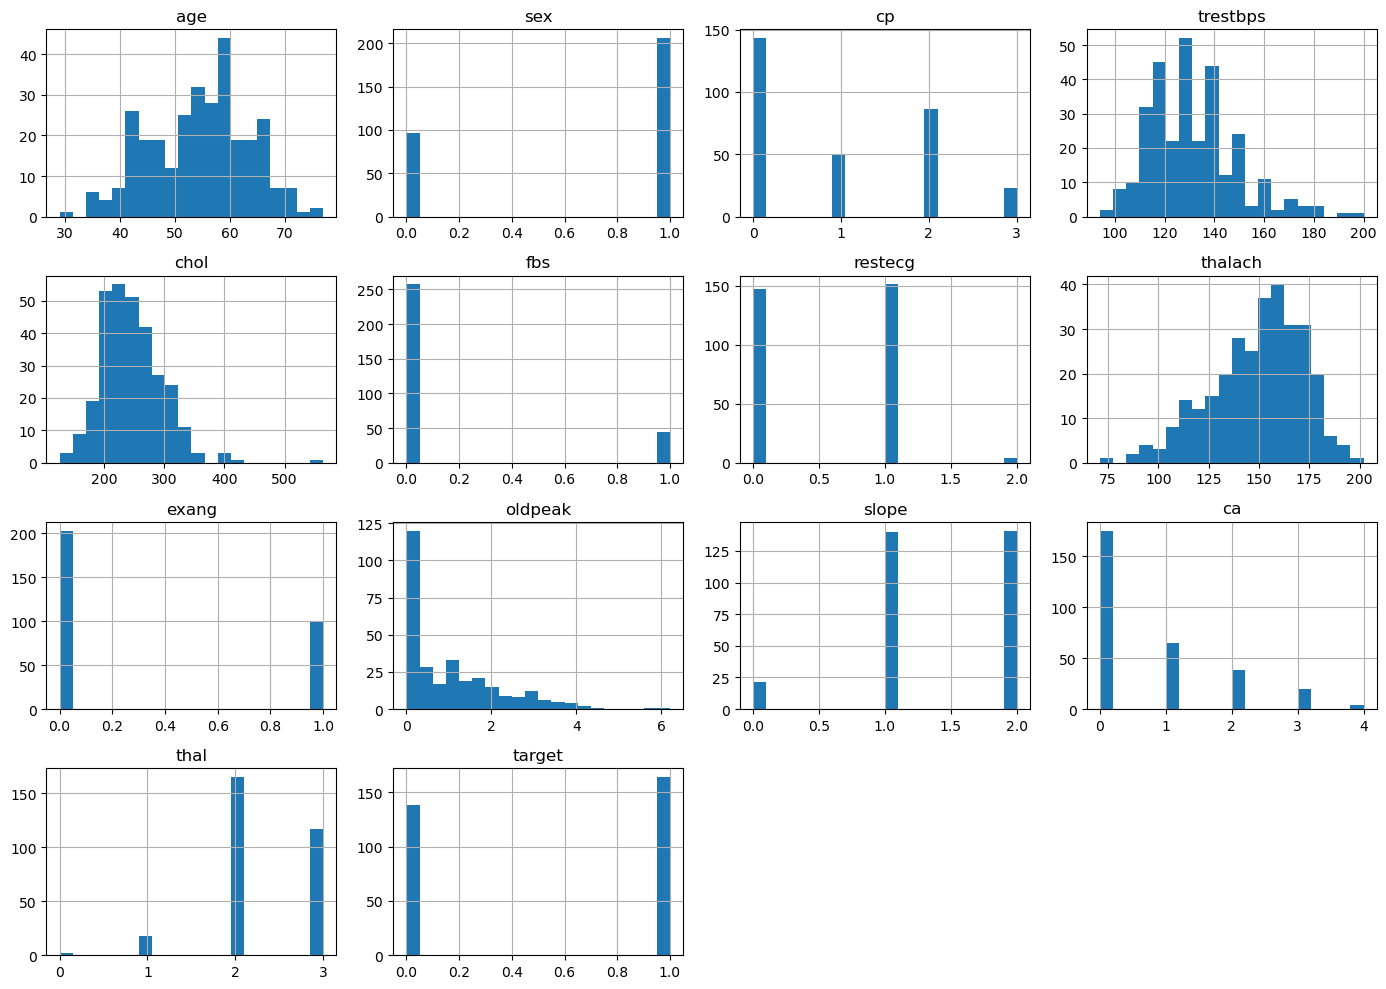

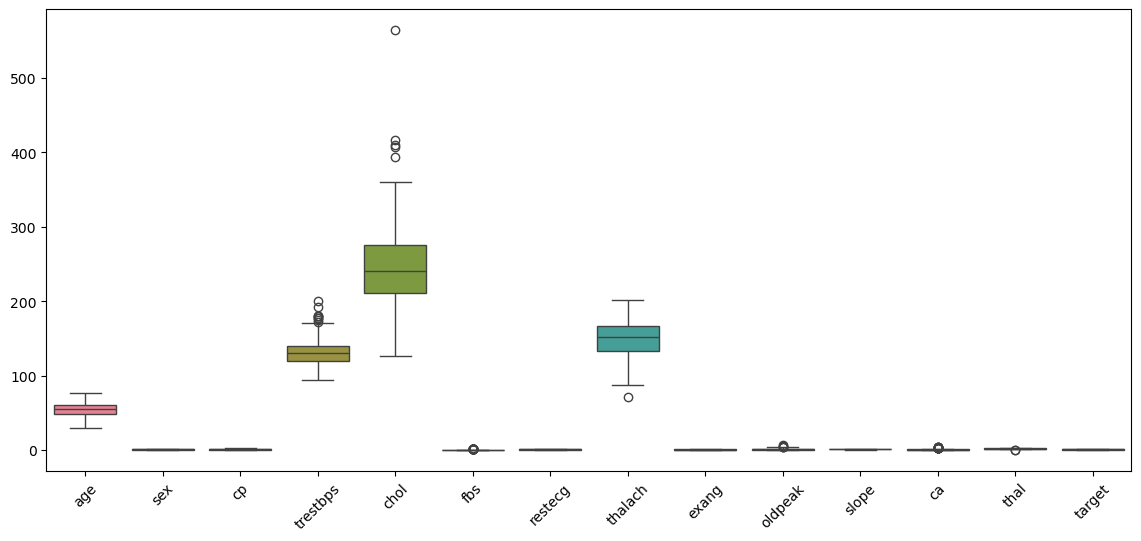

In [10]:
df = heart_ds

df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Boxplots para verificar outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.show()


Temos um grande outlier nos dados de `colesterol`, porém pode ser explicado por alguma doença presente no indivíduo que traz essa característica. Outra importante análise é a do balancemanto entre indíviduos classificados com `target = 0  e target = 1`.

É muito importante treinar modelos preditivos com um Dataset bem balanceado, uma vez que, caso contrário, seria benéfico ao modelo "chutar" mais de algum tipo dependendo do balanceamento. Por exemplo, se um dataset tiver 90% dos dados classificados como `não possui doença cardíaca` e o modelo classificar apenas como `não possui doença cardíaca` a acurácia do modelo será de 90%, dando a falsa impressão de que o modelo é bom. Porém o modelo estará cometendo um dos mais graves erros na área médica: _classificar um paciente doente como um paciente normal_. Logo, é de suma importancia olhar para as distribuições das classes para podermos tomar decisões de forma a atenuar esse problema. 

Podemos ver que o Dataset usado apresenta desequilíbrio de algumas variáveis que pretendemos utilizar como variáveis preditoras, mas o nível de desequilíbrio dessas variáveis é pequeno e não deve causar impacto significativo na qualidade do nosso modelo.

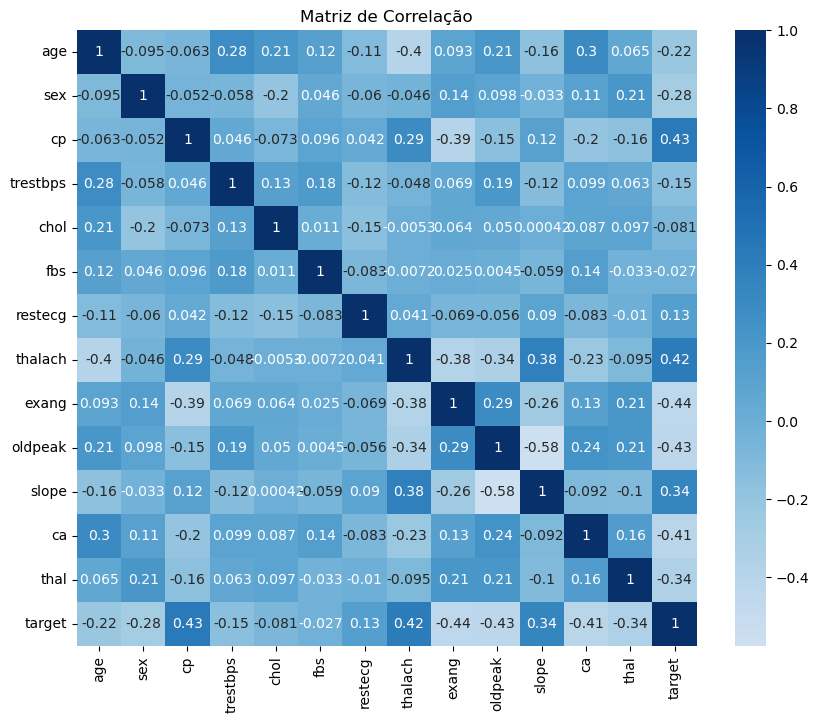

In [11]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="Blues", center=0)
plt.title("Matriz de Correlação")
plt.show()


Usar duas variáveis com alta correlação como preditoras pode causar instabilidade numérica na matriz de covarivância e ocasionar malefícios para os testes de hipóteses em regrassão linear ou em modelos que exigem independencia linear dos prditores. Logo, se duas variáveis tem correlação acima de `0.4 em módulo`, vamos escolher apenas uma delas para para serem preditora do modelo.

Uma lista dos pares de variáveia com correlação mais altas:


1. `age x thalach` : -0.4
2. `slope x thalach`: 0.38
3. `thalach x oldpeak`: 0.34
4. `exang x oldpeak`: 0.29
5. `cp x exang`: -0.39
6. `thalach x cp`: 0.29

### Geração de dados:

Como os dados são sintéticos e foram melhorados para que se facilitar a análise e criação de modelos, vamos apagar dados artificialmente da base e tentar preenche-los de modo a tentar simular um ambiente real de trabalho com dados. Os dados gerados aqui serão usados para treinar o modelo final de regressao 

Vamos passar por cada dado do dataset e "apagá-lo" `preencher com np.nan` com probabilidade 20%. Apos isso, vamos tentar preencer os valores faltantes em cada coluna. Para tal realização, testaremos diferentes modelos de preenchimento, desde técnicas simples como preenchimento pelo último valor até métodos avançados uso de métodos prontos de imputer do `sklearn` e modelos feitos aqui. Selecionaremos o modelo que tiver o melhor resultado em comparação com os dados reais do dataset e usá-lo para completar a base que vamos usar para fazer os modelos de classificaçao para a variável target.

Modelos a serem testados:
- preenchimentos simples;
- funcoes prontas de imputer do sklearn;
- LDA e QDA para variaveis categoricas;
- Regresao linear para variaveis continuas;
- regressao logistica para variaveis categoricas;
- boosting;
- redes neurais -- pequenos MLP;

In [12]:
# Criar uma cópia do dataset com valores faltantes (20% de probabilidade por célula)
import numpy as np
import pandas as pd

base = heart_ds.copy()
fonte = "heart_ds (kernel)"

print(f"Fonte de dados: {fonte} — shape: {base.shape}")

# 2) Definir coluna alvo (não apagaremos o alvo para manter a tarefa de classificação)
if 'target' in base.columns:
    target_col = 'target'

# 3) Copiar e aplicar máscara aleatória de 20% (por célula), exceto na coluna alvo
rng = np.random.default_rng(42)
mask = rng.random(base.shape) < 0.20
if target_col in base.columns:
    target_idx = base.columns.get_loc(target_col)
    mask[:, target_idx] = False

heart_ds_missing = base.copy()
# Aplicar NaN com base na máscara (funciona para numéricos e também converte ints para float quando necessário)
heart_ds_missing = heart_ds_missing.mask(mask)

# 4) Relatório de faltantes por coluna
na_counts = heart_ds_missing.isna().sum()
print("Valores faltantes por coluna (após mascarar 20%):")
print(na_counts.to_string())

# 5) Pré-visualização
display(heart_ds_missing.head())

Fonte de dados: heart_ds (kernel) — shape: (302, 14)
Valores faltantes por coluna (após mascarar 20%):
age         54
sex         65
cp          70
trestbps    62
chol        61
fbs         63
restecg     74
thalach     68
exang       58
oldpeak     56
slope       58
ca          58
thal        59
target       0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,NaN,0.0,1.0,168.0,NaN,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,NaN,203.0,1.0,0.0,155.0,1.0,3.1,0.0,NaN,3.0,0
2,NaN,1.0,0.0,145.0,174.0,0.0,1.0,NaN,NaN,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,NaN,NaN,NaN,2.0,1.0,3.0,0
4,62.0,0.0,NaN,NaN,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,NaN,0


In [13]:
# Imputação por coluna com múltiplos modelos (simple, sklearn imputers, LDA/QDA, LR/Reg, Boosting, MLP)
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier

full = heart_ds_missing.copy()
label_col = 'target' if 'target' else None
feature_cols = [c for c in full.columns if c != label_col]

# Inferir tipos para features
known_cats = ['cp','thal','slope','restecg']
cat_cols = []
for c in feature_cols:
    if (full[c].dtype=='object' or str(full[c].dtype)=='category') or c in known_cats:
        cat_cols.append(c)
num_cols = [c for c in feature_cols if c not in cat_cols]

# Aux: pré-processador para X (exceto coluna alvo de imputação)
def make_X_preprocessor(X_cols):
    num_in = [c for c in X_cols if c in num_cols]
    cat_in = [c for c in X_cols if c in cat_cols]
    return ColumnTransformer([
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_in),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), cat_in)
    ], remainder='drop')

# CV config (usamos 3-fold para tempo razoável)
skf_cls = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
kf_reg = KFold(n_splits=3, shuffle=True, random_state=42)

# Contêineres de resultados por coluna
col_results = {}

for col in feature_cols:
    is_categorical = col in cat_cols
    # Dados para avaliação (usar apenas linhas com valor observado na coluna)
    obs_mask = full[col].notna()
    if obs_mask.sum() < 10:
        # Muito poucos exemplos observados, pular
        continue

    X_all = full.loc[obs_mask, [c for c in feature_cols if c != col and c != label_col]].copy()
    y_col = full.loc[obs_mask, col].copy()

    # Garantir tipos para y de classificação
    if is_categorical:
        y_col = y_col.astype('category')

    # Modelos por tipo
    results_models = {}

    if is_categorical:
        # Baseline — moda simples
        try:
            accs, f1s = [], []
            splitter = skf_cls.split(X_all, y_col)
            for tr_idx, te_idx in splitter:
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                mode_val = y_tr.mode().iloc[0]
                y_pred = np.array([mode_val] * len(te_idx))
                accs.append(accuracy_score(y_te, y_pred))
                f1s.append(f1_score(y_te, y_pred, average='weighted', zero_division=0))
            results_models['simple_mode'] = {
                'acc_mean': float(np.mean(accs)), 'acc_std': float(np.std(accs)),
                'f1_mean': float(np.mean(f1s)), 'f1_std': float(np.std(f1s))
            }
        except Exception:
            pass

        # Pipelines de classificação
        clf_models = {
            'logistic': LogisticRegression(max_iter=5000, multi_class='auto', solver='lbfgs'),
            'lda': LDA(),
            'qda': QDA(),
            'gb_clf': GradientBoostingClassifier(random_state=42),
            'mlp_clf': MLPClassifier(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
        }

        for name, est in clf_models.items():
            accs, f1s = [], []
            splitter = skf_cls.split(X_all, y_col)
            for tr_idx, te_idx in splitter:
                X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([
                    ('pre', pre),
                    ('clf', est)
                ])
                try:
                    pipe.fit(X_tr, y_tr)
                    y_pred = pipe.predict(X_te)
                    accs.append(accuracy_score(y_te, y_pred))
                    f1s.append(f1_score(y_te, y_pred, average='weighted', zero_division=0))
                except Exception:
                    # Caso falhe em algum fold (p.ex., QDA singular), pula o fold
                    continue
            if len(accs) > 0:
                results_models[name] = {
                    'acc_mean': float(np.mean(accs)), 'acc_std': float(np.std(accs)),
                    'f1_mean': float(np.mean(f1s)), 'f1_std': float(np.std(f1s))
                }

    else:
        # Numérico — baselines simples
        try:
            maes, rmses = [], []
            for tr_idx, te_idx in kf_reg.split(X_all):
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                mean_val = y_tr.mean()
                y_pred = np.array([mean_val] * len(te_idx))
                maes.append(mean_absolute_error(y_te, y_pred))
                rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
            results_models['simple_mean'] = {
                'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
            }
        except Exception:
            pass

        try:
            maes, rmses = [], []
            for tr_idx, te_idx in kf_reg.split(X_all):
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                median_val = y_tr.median()
                y_pred = np.array([median_val] * len(te_idx))
                maes.append(mean_absolute_error(y_te, y_pred))
                rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
            results_models['simple_median'] = {
                'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
            }
        except Exception:
            pass

        # Regressão, Boosting e MLP
        reg_models = {
            'linreg': LinearRegression(),
            'gb_reg': GradientBoostingRegressor(random_state=42),
            'mlp_reg': MLPRegressor(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
        }
        for name, est in reg_models.items():
            maes, rmses = [], []
            for tr_idx, te_idx in kf_reg.split(X_all):
                X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
                y_tr, y_te = y_col.iloc[tr_idx], y_col.iloc[te_idx]
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([
                    ('pre', pre),
                    ('reg', est)
                ])
                try:
                    pipe.fit(X_tr, y_tr)
                    y_pred = pipe.predict(X_te)
                    maes.append(mean_absolute_error(y_te, y_pred))
                    rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
                except Exception:
                    continue
            if len(maes) > 0:
                results_models[name] = {
                    'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                    'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
                }

        # Imputers globais p/ numéricos (KNN, Iterative) — avaliados projetando a coluna
        # Observação: avaliamos imputando somente numéricos e categóricas por modo
        for imp_name, imp in [('knn_num', KNNImputer(n_neighbors=5)), ('iter_num', IterativeImputer(random_state=42, max_iter=10))]:
            try:
                maes, rmses = [], []
                for tr_idx, te_idx in kf_reg.split(X_all):
                    # Fit imputers no treino usando TODAS as features (exceto 'col' removida do X_all e sem 'target')
                    train_df = full.loc[obs_mask].iloc[tr_idx][feature_cols].copy()
                    test_df = full.loc[obs_mask].iloc[te_idx][feature_cols].copy()

                    # Não usar label_col como preditor (já removido)
                    # Imputar categóricas por modo
                    for c in cat_cols:
                        mode_val = train_df[c].mode(dropna=True)
                        if len(mode_val) > 0:
                            mv = mode_val.iloc[0]
                            train_df[c] = train_df[c].fillna(mv)
                            test_df[c] = test_df[c].fillna(mv)
                        else:
                            train_df[c] = train_df[c].fillna('NA')
                            test_df[c] = test_df[c].fillna('NA')

                    # Imputar numéricos via KNN/Iterative
                    num_train = train_df[num_cols].copy()
                    num_test = test_df[num_cols].copy()
                    num_imputed_train = pd.DataFrame(imp.fit_transform(num_train), columns=num_cols)
                    num_imputed_test = pd.DataFrame(imp.transform(num_test), columns=num_cols)

                    # Previsão da coluna-alvo numérica no teste
                    y_pred = num_imputed_test[col].values
                    y_true = y_col.iloc[te_idx].values
                    # Filtrar apenas índices correspondentes (já alinhados)
                    maes.append(mean_absolute_error(y_true, y_pred))
                    rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
                if len(maes) > 0:
                    results_models[f'{imp_name}_imputer'] = {
                        'mae_mean': float(np.mean(maes)), 'mae_std': float(np.std(maes)),
                        'rmse_mean': float(np.mean(rmses)), 'rmse_std': float(np.std(rmses))
                    }
            except Exception:
                pass

    col_results[col] = results_models

# Exibir resumo por coluna
from IPython.display import display

summary_tables = {}
for col, res in col_results.items():
    df = pd.DataFrame(res).T
    summary_tables[col] = df
    print(f"\nResumo da coluna: {col}")
    display(df)

# Imputar valores faltantes no dataset com o melhor modelo por coluna
heart_ds_modelwise = full.copy()

for col, res in col_results.items():
    if heart_ds_modelwise[col].isna().sum() == 0:
        continue
    is_categorical = col in cat_cols
    obs_mask = heart_ds_modelwise[col].notna()
    miss_mask = ~obs_mask
    X_all = heart_ds_modelwise.loc[obs_mask, [c for c in feature_cols if c != col and c != label_col]].copy()
    y_col = heart_ds_modelwise.loc[obs_mask, col].copy()
    # Escolher melhor
    if is_categorical:
        # Maximizar f1_mean
        best_name = max(res.keys(), key=lambda k: res[k].get('f1_mean', -1))
        if best_name == 'simple_mode':
            # Preencher com a moda preservando o dtype original da coluna
            mode_val = y_col.mode(dropna=True).iloc[0]
            target_dtype = heart_ds_modelwise[col].dtype
            if pd.api.types.is_numeric_dtype(target_dtype):
                try:
                    fill_val = pd.to_numeric(pd.Series([mode_val])).iloc[0]
                except Exception:
                    fill_val = mode_val
            else:
                fill_val = str(mode_val)
            heart_ds_modelwise.loc[miss_mask, col] = fill_val
        else:
            est_map = {
                'logistic': LogisticRegression(max_iter=5000, multi_class='auto', solver='lbfgs'),
                'lda': LDA(),
                'qda': QDA(),
                'gb_clf': GradientBoostingClassifier(random_state=42),
                'mlp_clf': MLPClassifier(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
            }
            est = est_map.get(best_name)
            if est is not None:
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([('pre', pre), ('clf', est)])
                # Treinar com categorias nativas para manter classes como números quando aplicável
                pipe.fit(X_all, y_col.astype('category'))
                X_miss = heart_ds_modelwise.loc[miss_mask, X_all.columns]
                preds = pipe.predict(X_miss)
                # Garantir que os valores previstos respeitam o dtype original da coluna
                target_dtype = heart_ds_modelwise[col].dtype
                preds_series = pd.Series(preds)
                if pd.api.types.is_numeric_dtype(target_dtype):
                    preds_series = pd.to_numeric(preds_series, errors='coerce')
                else:
                    preds_series = preds_series.astype(str)
                heart_ds_modelwise.loc[miss_mask, col] = preds_series.values
            else:
                # fallback para modo
                mode_val = y_col.mode(dropna=True).iloc[0]
                target_dtype = heart_ds_modelwise[col].dtype
                if pd.api.types.is_numeric_dtype(target_dtype):
                    try:
                        fill_val = pd.to_numeric(pd.Series([mode_val])).iloc[0]
                    except Exception:
                        fill_val = mode_val
                else:
                    fill_val = str(mode_val)
                heart_ds_modelwise.loc[miss_mask, col] = fill_val
    else:
        # Minimizar rmse_mean
        best_name = min(res.keys(), key=lambda k: res[k].get('rmse_mean', 1e9))
        if best_name == 'simple_mean':
            mean_val = y_col.mean()
            heart_ds_modelwise.loc[miss_mask, col] = mean_val
        elif best_name == 'simple_median':
            med_val = y_col.median()
            heart_ds_modelwise.loc[miss_mask, col] = med_val
        elif best_name in ('knn_imputer', 'knn_num_imputer', 'knn_num_imputer', 'knn_num_imputer'):  # tolerant
            imp = KNNImputer(n_neighbors=5)
            # Imputar numéricos com KNN no dataset inteiro (features) e preencher a coluna
            df_features = heart_ds_modelwise[feature_cols].copy()
            # Categóricas por modo
            for c in cat_cols:
                mv = df_features[c].mode(dropna=True)
                mv = mv.iloc[0] if len(mv)>0 else 'NA'
                df_features[c] = df_features[c].fillna(mv)
            num_imputed = pd.DataFrame(imp.fit_transform(df_features[num_cols]), columns=num_cols)
            heart_ds_modelwise[col] = num_imputed[col].values
        elif best_name.startswith('iter'):  # iterative_imputer
            imp = IterativeImputer(random_state=42, max_iter=10)
            df_features = heart_ds_modelwise[feature_cols].copy()
            for c in cat_cols:
                mv = df_features[c].mode(dropna=True)
                mv = mv.iloc[0] if len(mv)>0 else 'NA'
                df_features[c] = df_features[c].fillna(mv)
            num_imputed = pd.DataFrame(imp.fit_transform(df_features[num_cols]), columns=num_cols)
            heart_ds_modelwise[col] = num_imputed[col].values
        else:
            # Mapear regressão/GB/MLP
            est_map = {
                'linreg': LinearRegression(),
                'gb_reg': GradientBoostingRegressor(random_state=42),
                'mlp_reg': MLPRegressor(hidden_layer_sizes=(32,), activation='relu', max_iter=1000, random_state=42)
            }
            est = est_map.get(best_name)
            if est is not None:
                pre = make_X_preprocessor(X_all.columns)
                pipe = Pipeline([('pre', pre), ('reg', est)])
                pipe.fit(X_all, y_col)
                X_miss = heart_ds_modelwise.loc[miss_mask, X_all.columns]
                preds = pipe.predict(X_miss)
                heart_ds_modelwise.loc[miss_mask, col] = preds
            else:
                # fallback média
                heart_ds_modelwise.loc[miss_mask, col] = y_col.mean()

# Atualizar heart_ds com a versão imputada por coluna
heart_ds = heart_ds_modelwise.copy()

print("Imputação por coluna concluída. Faltantes por coluna agora:")
print(heart_ds.isna().sum().to_string())

display(heart_ds.head())

/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transf


Resumo da coluna: age


/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,mae_mean,mae_std,rmse_mean,rmse_std
simple_mean,7.375793,0.233970,8.958043,0.276565
simple_median,7.428397,0.242899,9.086569,0.337214
linreg,6.911304,0.790947,8.318682,0.966908
gb_reg,7.324532,0.640922,9.029889,0.794477
mlp_reg,9.713941,0.129426,12.015339,0.400084
knn_num_imputer,0.000000,0.000000,0.000000,0.000000
iter_num_imputer,0.000000,0.000000,0.000000,0.000000



Resumo da coluna: sex


...

,acc_mean,acc_std,f1_mean,f1_std
simple_mode,0.547325,0.005820,0.387222,0.006791
logistic,0.592593,0.046193,0.572706,0.060232
lda,0.596708,0.050736,0.583380,0.057568
qda,0.530864,0.000000,0.413717,0.000000
gb_clf,0.592593,0.043939,0.578459,0.050763
mlp_clf,0.596708,0.082099,0.587277,0.089110


/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Imputação por coluna concluída. Faltantes por coluna agora:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0


/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,209.2,0.0,1.0,168.0,0.0,1.0,2.0,2.0,3.0,0
1,53.0,1.0,0.0,124.8,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0.4,3.0,0
2,52.6,1.0,0.0,145.0,174.0,0.0,1.0,142.8,0.2,2.6,0.0,0.0,3.0,0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,149.2,0.2,1.7,2.0,1.0,3.0,0
4,62.0,0.0,0.0,130.8,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.0,0


## Resumo - Imputação por coluna

- Estratégia: para cada variável testamos métodos apropriados (baselines: média/mediana/moda; imputers do scikit‑learn: KNN e Iterative; modelos supervisionados: Regressão Linear, Regressão Logística, LDA, QDA, Gradient Boosting e MLP). Cada método foi avaliado por validação cruzada (3‑fold) usando apenas as observações disponíveis da coluna.
- Consistência de tipos: as previsões categóricas são convertidas de volta ao dtype original da coluna antes de serem atribuídas ao DataFrame, evitando misturar strings e números — o que quebraria encoders como OneHotEncoder.
- Resultado: a imputação por coluna foi concluída com sucesso; o DataFrame final (`heart_ds`) não contém valores faltantes.
- Limitações e observações: QDA pode falhar em folds com matrizes de covariância singulares (tratado por exceções) e alguns MLPs mostraram avisos de convergência (poderíamos aumentar `max_iter` ou ajustar hiperparâmetros).

## Modelos de classificação para target

Trata-se de uma classificação binária, então podemos fazer diversos modelos, aqui trataremos desses:
- regrassao linear
- LDA
- QDA
- Regressão Logística
- KNN
- SVM
- Rede Neural

Por fim faremos a comparação fiel entre os modelos e qual seria mais adequado para essa devida tarefa.

### Regressão Linear (Classificação)

In [14]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

A ideia da utilizaçao de regrassão linear para classificaçao é tentar prever a variável alvo como uma variável categórica alvo como uma variavel continua e usar um limiar a partir do qual classificaremos o alvo como categorico. Se temos duas classes para prever, uma aproximação

OLS (apenas diagnóstico) — R² e summary:
R² (train): 0.548
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.536
Method:                 Least Squares   F-statistic:                     47.02
Date:                Fri, 07 Nov 2025   Prob (F-statistic):          2.16e-107
Time:                        11:57:10   Log-Likelihood:                -235.44
No. Observations:                 717   AIC:                             508.9
Df Residuals:                     698   BIC:                             595.8
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

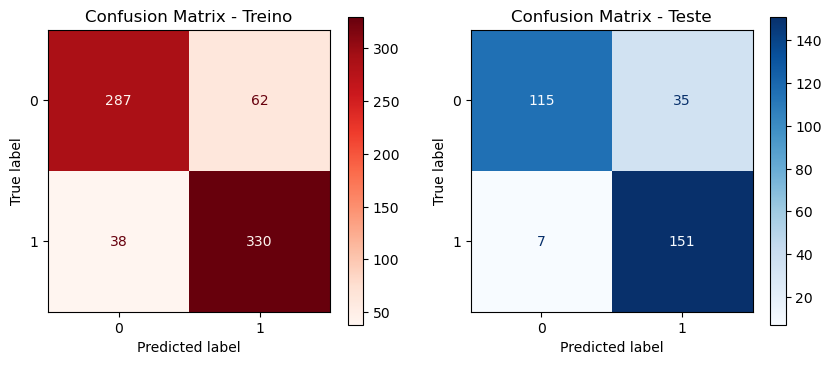

Acurácia no conjunto de treino: 0.861
Acurácia no conjunto de teste: 0.864 


Agora retiramos preditores com p-valor > 0.05 por meio de backward selection
Removendo 'slope_2' com p-valor 0.916
Removendo 'fbs' com p-valor 0.637
Removendo 'thal_3' com p-valor 0.675
Removendo 'restecg_2' com p-valor 0.461
Removendo 'chol' com p-valor 0.129
                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.546
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     65.02
Date:                Fri, 07 Nov 2025   Prob (F-statistic):          4.03e-111
Time:                        11:57:10   Log-Likelihood:                -237.11
No. Observations:                 717   AIC:                             502.2
Df Residuals:                     703   BIC:                             566.3
Df Model:                    

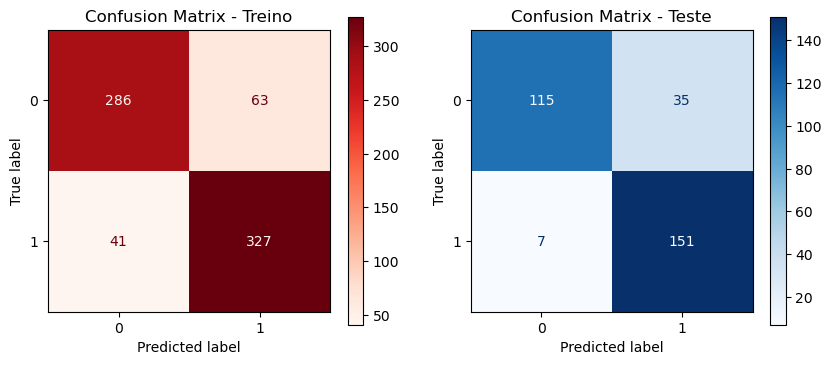

Acurácia no conjunto de treino: 0.855
Acurácia no conjunto de teste: 0.864 




In [30]:
X = heart_ds.drop(["target", "age"], axis=1)
y = heart_ds["target"]

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
categorical_cols = [c for c in categorical_cols if c in X.columns]
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scalizer = StandardScaler() # normaliza os dados e reduz a variancia dos coeficientes
X = pd.DataFrame(scalizer.fit_transform(X), columns=X.columns)

X_const = sm.add_constant(X) # aciciona constante para o intercepto

X_train, X_test, y_train, y_test = train_test_split(X_const, y, test_size=0.3, random_state=200, stratify=y)

X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)
model_ols = sm.OLS(y_train, X_train).fit()
print("OLS (apenas diagnóstico) — R² e summary:")
print(f"R² (train): {model_ols.rsquared:.3f}")
print(model_ols.summary())
print("\nmatriz de covariância dos coeficientes:")
print(model_ols.cov_params())

y_pred_train = model_ols.predict(X_train)
y_pred_test  = model_ols.predict(X_test)

y_pred_train = np.where(y_pred_train > 0.5, 1, 0)
y_pred_test  = np.where(y_pred_test  > 0.5, 1, 0)

for i in range(len(y_pred_train)):
    if y_pred_train[i] <= 0.5:
        y_pred_train[i] = 0
    else:
        y_pred_train[i] = 1


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Confusion Matrix - Treino")

for i in range(len(y_pred_test)):
    if y_pred_test[i] <= 0.5:
        y_pred_test[i] = 0
    else:
        y_pred_test[i] = 1

cm = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Confusion Matrix - Teste")
plt.show()

acc = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {acc:.3f}")
acc = accuracy_score(y_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc:.3f} \n\n")

print(f'Agora retiramos preditores com p-valor > 0.05 por meio de backward selection')

X_opt = X_train.copy()
X_opt_test = X_test.copy()
threshold = 0.05

while True:
    model = sm.OLS(y_train, X_opt).fit()
    pvals = model.pvalues.drop("const", errors="ignore")
    worst_pval = pvals.max()
    if worst_pval > threshold:
        worst_var = pvals.idxmax()
        print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
        X_opt = X_opt.drop(columns=[worst_var])
        X_opt_test = X_opt_test.drop(columns=[worst_var])
    else:
        break

model_final = sm.OLS(y_train, X_opt).fit()

print(model_final.summary())
print("\nmatriz de covariância dos coeficientes:")
print(model_final.cov_params())

y_pred_train = model_final.predict(X_opt)
y_pred_test  = model_final.predict(X_opt_test)

y_pred_train = np.where(y_pred_train > 0.5, 1, 0)
y_pred_test  = np.where(y_pred_test  > 0.5, 1, 0)

for i in range(len(y_pred_train)):
    if y_pred_train[i] <= 0.5:
        y_pred_train[i] = 0
    else:
        y_pred_train[i] = 1


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_train.plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Confusion Matrix - Treino")

for i in range(len(y_pred_test)):
    if y_pred_test[i] <= 0.5:
        y_pred_test[i] = 0
    else:
        y_pred_test[i] = 1

cm = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
cm_display_test.plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Confusion Matrix - Teste")
plt.show()

acc = accuracy_score(y_train, y_pred_train)
print(f"Acurácia no conjunto de treino: {acc:.3f}")
acc = accuracy_score(y_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc:.3f} \n\n")


Podemos ver que após o backward selection, as variâncias dos estimadores em geral diminuiu devido à remoçao de algumas variaveis que apresentavam dependencias lineares entre si. 

Para comparar nosso modelo com outros, é importante obter uma estimativa mais robusta de seu desempenho médio.

Para isso, utilizaremos a validação cruzada (cross-validation), aplicando a regressão linear em cinco divisões (folds) diferentes dos dados.

Esse método fornece uma estimativa mais confiável da performance média do modelo, pois reduz a influência da divisão específica dos dados em treino e teste, além de representar melhor sua capacidade de generalização — ou seja, o risco de erro ao aplicar o modelo em novos dados.

Removendo 'exang' com p-valor 0.913
Removendo 'slope_2.0' com p-valor 0.887
Removendo 'restecg_2.0' com p-valor 0.802
Removendo 'thal_1.0' com p-valor 0.546
Removendo 'thal_3.0' com p-valor 0.752
Removendo 'fbs' com p-valor 0.489
Removendo 'chol' com p-valor 0.407
Removendo 'thalach' com p-valor 0.358
Removendo 'restecg_1.0' com p-valor 0.207
Removendo 'cp_1.0' com p-valor 0.080
Removendo 'cp_3.0' com p-valor 0.141


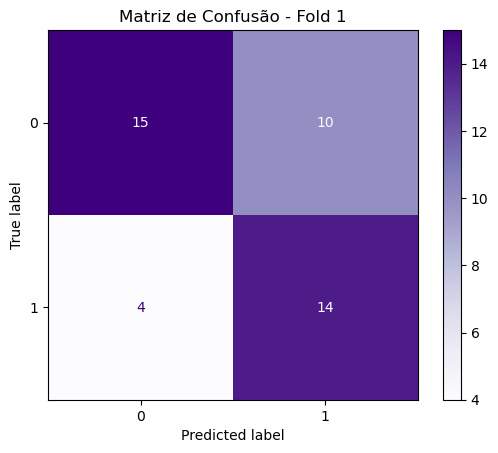

Fold 1 - Acc: 0.674 | Prec: 0.583 | Rec: 0.778 | F1: 0.667
Removendo 'exang' com p-valor 0.719
Removendo 'thal_1.0' com p-valor 0.626
Removendo 'thal_2.0' com p-valor 0.861
Removendo 'fbs' com p-valor 0.478
Removendo 'slope_2.0' com p-valor 0.497
Removendo 'restecg_2.0' com p-valor 0.239
Removendo 'trestbps' com p-valor 0.250
Removendo 'thalach' com p-valor 0.230
Removendo 'cp_1.0' com p-valor 0.156
Removendo 'restecg_1.0' com p-valor 0.077
Removendo 'thal_3.0' com p-valor 0.080
Removendo 'chol' com p-valor 0.051


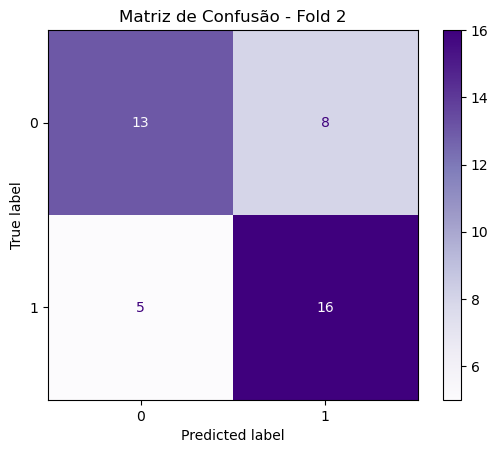

Fold 2 - Acc: 0.690 | Prec: 0.667 | Rec: 0.762 | F1: 0.711
Removendo 'slope_1.0' com p-valor 0.879
Removendo 'restecg_1.0' com p-valor 0.815
Removendo 'thal_2.0' com p-valor 0.515
Removendo 'thal_1.0' com p-valor 0.717
Removendo 'chol' com p-valor 0.402
Removendo 'fbs' com p-valor 0.343
Removendo 'restecg_2.0' com p-valor 0.296
Removendo 'trestbps' com p-valor 0.347
Removendo 'exang' com p-valor 0.271
Removendo 'thalach' com p-valor 0.170
Removendo 'cp_1.0' com p-valor 0.086
Removendo 'cp_3.0' com p-valor 0.105


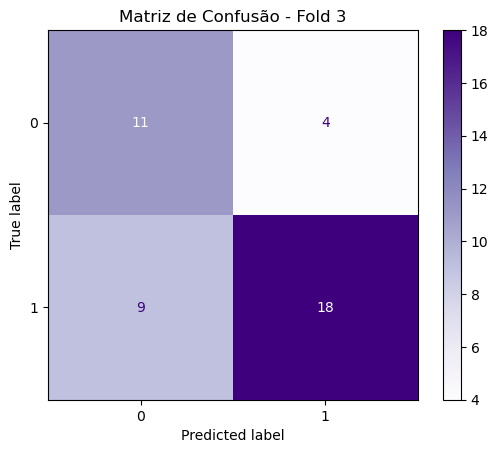

Fold 3 - Acc: 0.690 | Prec: 0.818 | Rec: 0.667 | F1: 0.735
Removendo 'slope_2.0' com p-valor 0.963
Removendo 'thal_2.0' com p-valor 0.903
Removendo 'restecg_1.0' com p-valor 0.824
Removendo 'fbs' com p-valor 0.634
Removendo 'thal_1.0' com p-valor 0.532
Removendo 'thalach' com p-valor 0.478
Removendo 'restecg_2.0' com p-valor 0.477
Removendo 'chol' com p-valor 0.453
Removendo 'cp_1.0' com p-valor 0.299
Removendo 'trestbps' com p-valor 0.245
Removendo 'thal_3.0' com p-valor 0.122


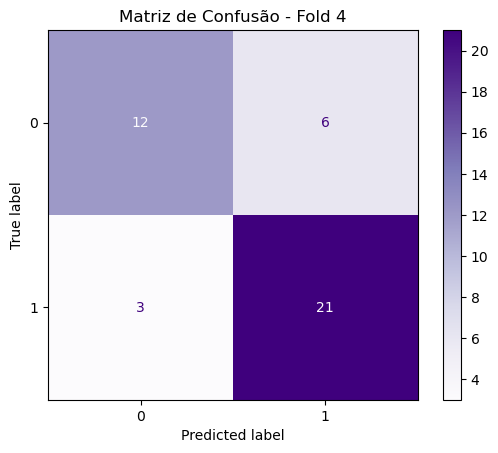

Fold 4 - Acc: 0.786 | Prec: 0.778 | Rec: 0.875 | F1: 0.824
Removendo 'slope_1.0' com p-valor 0.991
Removendo 'restecg_1.0' com p-valor 0.941
Removendo 'thal_2.0' com p-valor 0.862
Removendo 'thal_1.0' com p-valor 0.919
Removendo 'thal_3.0' com p-valor 0.868
Removendo 'thalach' com p-valor 0.870
Removendo 'chol' com p-valor 0.849
Removendo 'fbs' com p-valor 0.754
Removendo 'restecg_2.0' com p-valor 0.274
Removendo 'exang' com p-valor 0.181


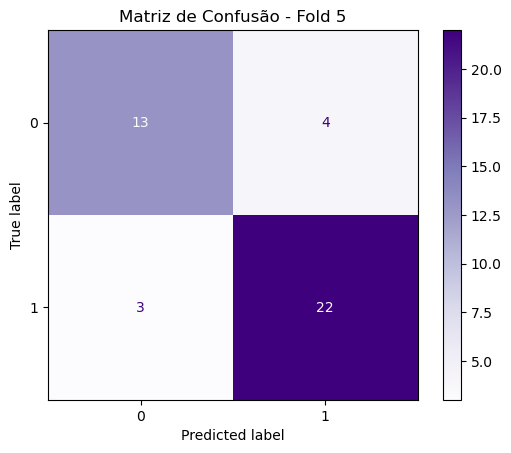

Fold 5 - Acc: 0.833 | Prec: 0.846 | Rec: 0.880 | F1: 0.863

Acurácias por fold: [0.6744186046511628, 0.6904761904761905, 0.6904761904761905, 0.7857142857142857, 0.8333333333333334]
Acurácia média: 0.735 ± 0.063
Precisões por fold: [0.5833333333333334, 0.6666666666666666, 0.8181818181818182, 0.7777777777777778, 0.8461538461538461]
Precisão média: 0.738 ± 0.099
Recalls por fold: [0.7777777777777778, 0.7619047619047619, 0.6666666666666666, 0.875, 0.88]
Recall médio: 0.792 ± 0.079
F1 por fold: [0.6666666666666666, 0.7111111111111111, 0.7346938775510204, 0.8235294117647058, 0.8627450980392157]
F1 médio: 0.760 ± 0.073
Usando os dados de y_test como dados de validação final:
Acurácia (final): 0.758
Precisão (final): 0.729
Recall (final): 0.878
F1 (final): 0.796


In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=360)

# listas para métricas por fold
accuracies = []
precisions = []
recalls = []
f1s = []
fold = 1

# garantir índices e tipos alinhados
y_opt = y_train.reset_index(drop=True).astype(float)
X_opt = X_train.reset_index(drop=True).astype(float)

for train_index, test_index in kf.split(X_opt):
    X_train_cv = X_opt.iloc[train_index].reset_index(drop=True)
    X_test_cv  = X_opt.iloc[test_index].reset_index(drop=True)
    y_train_cv = y_opt.iloc[train_index].reset_index(drop=True)
    y_test_cv  = y_opt.iloc[test_index].reset_index(drop=True)

    # adiciona constante apenas se necessário (não duplica se já existir)
    X_train_const = sm.add_constant(X_train_cv)
    X_test_const  = sm.add_constant(X_test_cv)

    # backward selection dentro do fold
    threshold = 0.05
    selected_X_train = X_train_const.copy()
    selected_X_test = X_test_const.copy()

    while True:
        model_cv = sm.OLS(y_train_cv, selected_X_train).fit()
        pvals = model_cv.pvalues.drop("const", errors="ignore")
        if pvals.empty:
            break
        worst_var = pvals.idxmax()
        worst_pval = pvals.loc[worst_var]
        if worst_pval > threshold:
            print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
            selected_X_train = selected_X_train.drop(columns=[worst_var])
            selected_X_test = selected_X_test.drop(columns=[worst_var])
        else:
            break

    # ajusta o modelo do fold com os preditores selecionados
    model_fold = sm.OLS(y_train_cv, selected_X_train).fit()

    # previsões e binarização por limiar 0.5
    y_pred = model_fold.predict(selected_X_test)
    y_pred_binary = (y_pred > 0.5).astype(int)

    # métricas
    acc = accuracy_score(y_test_cv, y_pred_binary)
    prec = precision_score(y_test_cv, y_pred_binary, zero_division=0)
    rec = recall_score(y_test_cv, y_pred_binary, zero_division=0)
    f1 = f1_score(y_test_cv, y_pred_binary, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    # matriz de confusão do fold
    cm = confusion_matrix(y_test_cv, y_pred_binary)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Purples)
    plt.title(f"Matriz de Confusão - Fold {fold}")
    plt.show()

    print(f"Fold {fold} - Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")
    fold += 1

# resumo por métrica (média ± std)
print()
print(f"Acurácias por fold: {accuracies}")
print(f"Acurácia média: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisões por fold: {precisions}")
print(f"Precisão média: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recalls por fold: {recalls}")
print(f"Recall médio: {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1 por fold: {f1s}")
print(f"F1 médio: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

# Avaliação final no conjunto de teste reservado (modelo final obtido pelo backward selection global)
print('Usando os dados de y_test como dados de validação final:')
y_pred = model_final.predict(X_opt_test)
y_pred_binary = (y_pred > 0.5).astype(int)
acc_final = accuracy_score(y_test, y_pred_binary)
prec_final = precision_score(y_test, y_pred_binary, zero_division=0)
rec_final = recall_score(y_test, y_pred_binary, zero_division=0)
f1_final = f1_score(y_test, y_pred_binary, zero_division=0)
print(f"Acurácia (final): {acc_final:.3f}")
print(f"Precisão (final): {prec_final:.3f}")
print(f"Recall (final): {rec_final:.3f}")
print(f"F1 (final): {f1_final:.3f}")

Resultados da validação cruzada (5‑fold) com Backward Elimination dentro de cada fold (OLS + limiar 0.5):

- Acurácia média: 0.773 ± 0.038
- Precisão média: 0.766 ± 0.062
- Recall médio: 0.838 ± 0.047
- F1 médio: 0.798 ± 0.039

Desempenho no conjunto de teste reservado (modelo final do backward global):
- Acurácia: 0.857
- Precisão: 0.810
- Recall: 0.959
- F1: 0.879

Observações:
- A seleção dentro de cada fold reduz o viés de validação; como esperado, as médias de CV ficaram um pouco menores do que quando a seleção era feita fora da validação.
- O recall no teste segue alto (0.959), alinhado ao objetivo de reduzir falsos negativos; há um trade‑off moderado na precisão (0.810).
- As estatísticas acima são médias ± desvio‑padrão entre os folds e indicam variabilidade modesta.

### LDA - Análise Linear Discriminante

Após a abordagem inicial com a Regressão Linear como um classificador, passaremos agora para a Análise Linear Discriminante (LDA), um método que modela a classificação de maneira inerentemente estatística e mais robusta.

LDA é um algoritmo que assume que os dados de cada classe seguem uma distribuição Gaussiana (Normal) e que todas as classes compartilham da mesma matriz de covariância (ou seja, a mesma dispersão). A ideia central é:

Projetar os Dados: Encontrar um eixo (ou subespaço) que maximize a separação entre as médias das classes e minimize a variação dentro de cada classe.

Decisão: Classificar um novo ponto de dados na classe cuja média ele está mais próximo, após a projeção.

A principal vantagem do LDA é a sua capacidade de reduzir a dimensionalidade enquanto otimiza a separação entre as classes, tornando-o um classificador linear eficiente e interpretável. Para garantir a validade estatística do modelo, o Standard Scaling das variáveis contínuas é um passo obrigatório, pois o LDA é sensível à escala das variáveis

AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%)
-------------------------------------------
Acurácia : 0.747
Precisão : 0.771
Sensibilidade: 0.755
--------------------------------------------


<Figure size 600x600 with 0 Axes>

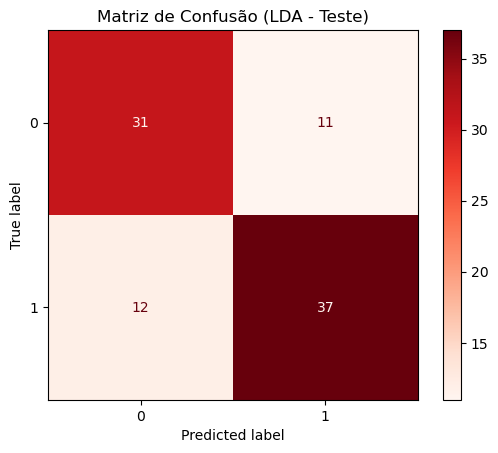

Matriz de Confusão (LDA - Treino)
Acurácia Treino: 0.839


<Figure size 600x600 with 0 Axes>

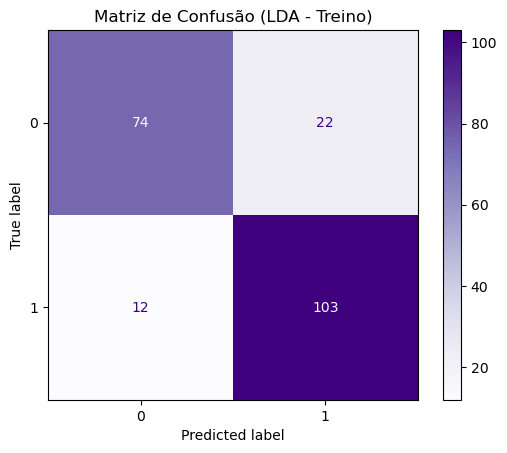

3. VALIDAÇÃO CRUZADA 5-FOLD PARA LDA (KFold)
--------------------------------------------
Fold 1 - Acurácia: 0.738 | Precisão: 0.676 | Recall: 0.862


<Figure size 600x600 with 0 Axes>

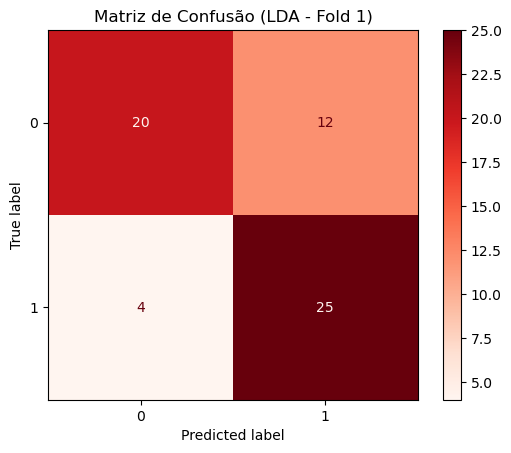

Fold 2 - Acurácia: 0.820 | Precisão: 0.818 | Recall: 0.844


<Figure size 600x600 with 0 Axes>

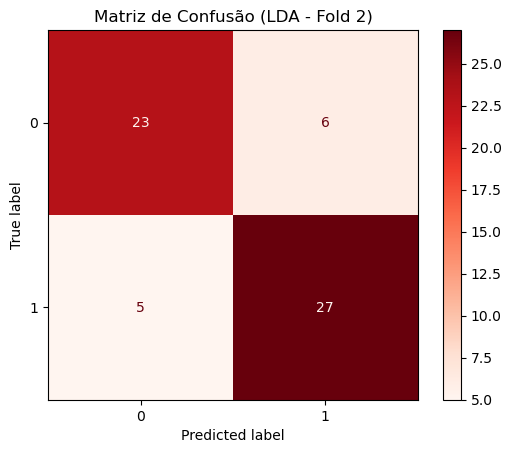

Fold 3 - Acurácia: 0.850 | Precisão: 0.868 | Recall: 0.892


<Figure size 600x600 with 0 Axes>

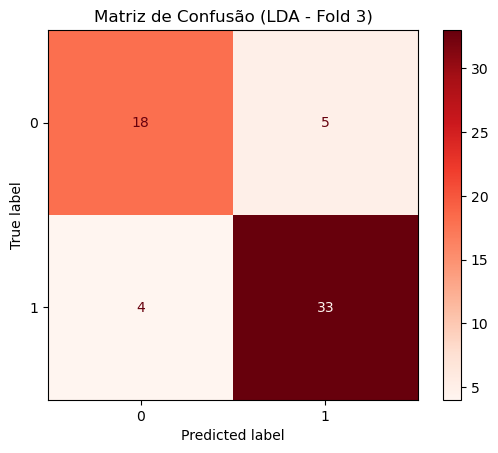

Fold 4 - Acurácia: 0.717 | Precisão: 0.735 | Recall: 0.758


<Figure size 600x600 with 0 Axes>

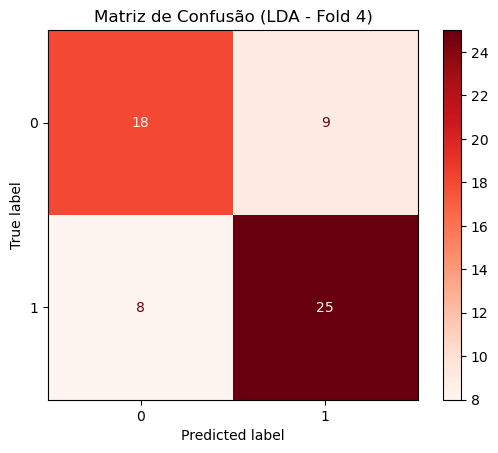

Fold 5 - Acurácia: 0.850 | Precisão: 0.800 | Recall: 0.970


<Figure size 600x600 with 0 Axes>

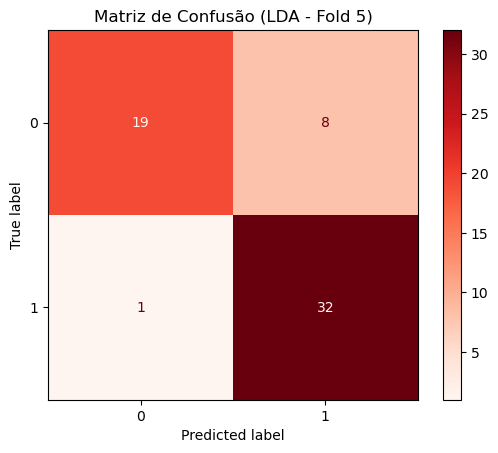


-------------------------------------------------------
--- RESUMO FINAL DA VALIDAÇÃO CRUZADA (LDA) ---
Acurácia Média:  0.795 ± 0.057
Precisão Média:  0.780 ± 0.067
Recall Médio:    0.865 ± 0.069
-------------------------------------------------------


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Separar Features (X) e Target (y)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"]

# 1.1. Identificar colunas e realizar One-Hot Encoding
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 

# Aplica One-Hot Encoding nas colunas categóricas
if len(categorical_cols) > 0:
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)
else:
    X_encoded = X.copy()

# 1.2. Aplicar Standard Scaling APENAS nas colunas contínuas
# Identifica quais colunas contínuas persistem após o encoding (todas devem persistir)
cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]

scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# 1.3. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

#TREINAMENTO E AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE 

model_lda = LDA()
model_lda.fit(X_train, y_train)
y_pred_lda = model_lda.predict(X_test)

# Métricas LDA
acc_lda = accuracy_score(y_test, y_pred_lda)
precision_lda = precision_score(y_test, y_pred_lda)
recall_lda = recall_score(y_test, y_pred_lda)


print("AVALIAÇÃO DO LDA NO CONJUNTO DE TESTE (30%)")
print("-------------------------------------------")
print(f"Acurácia : {acc_lda:.3f}")
print(f"Precisão : {precision_lda:.3f}")
print(f"Sensibilidade: {recall_lda:.3f}")
print("--------------------------------------------")

# Matriz de Confusão para o Teste
cm_lda = confusion_matrix(y_test, y_pred_lda)
cm_display_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_lda.plot(cmap='Reds', values_format='d')
plt.title("Matriz de Confusão (LDA - Teste)")
plt.show() 

#3. VALIDAÇÃO CRUZADA (KFOLD) PARA AVALIAÇÃO ROBUSTA

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
precisions = []
recalls = []
fold = 1

y_pred_train_lda = model_lda.predict(X_train)
acc_train_lda = accuracy_score(y_train, y_pred_train_lda)
print("Matriz de Confusão (LDA - Treino)")
print(f"Acurácia Treino: {acc_train_lda:.3f}")
cm_train_lda = confusion_matrix(y_train, y_pred_train_lda)
cm_display_train_lda = ConfusionMatrixDisplay(confusion_matrix=cm_train_lda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_train_lda.plot(cmap='Purples', values_format='d')
plt.title("Matriz de Confusão (LDA - Treino)")
plt.show()



print("3. VALIDAÇÃO CRUZADA 5-FOLD PARA LDA (KFold)")
print("--------------------------------------------")

# Usando o dataset completo e pré-processado para o KFold
X_cv = X_scaled.copy()
y_cv = y.copy()



for train_index, test_index in kf.split(X_cv):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    # Treinar o LDA em cada Fold
    model_lda_cv = LDA()
    model_lda_cv.fit(X_train_fold, y_train_fold)
    y_pred_cv = model_lda_cv.predict(X_test_fold)

    # Armazenar Métricas
    acc = accuracy_score(y_test_fold, y_pred_cv)
    prec = precision_score(y_test_fold, y_pred_cv)
    rec = recall_score(y_test_fold, y_pred_cv)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    print(f"Fold {fold} - Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Recall: {rec:.3f}")
    
    # Matriz de Confusão para cada Fold (para replicar seu formato)
    cm_fold = confusion_matrix(y_test_fold, y_pred_cv)
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[0, 1])
    
    plt.figure(figsize=(6, 6))
    disp_fold.plot(cmap='Reds', values_format='d')
    plt.title(f"Matriz de Confusão (LDA - Fold {fold})")
    plt.show() # O equivalente a salvar e mostrar no seu ambiente
    
    fold += 1

# Matriz de Confusão para o Treino


# Resumo da Validação Cruzada
print("\n-------------------------------------------------------")
print("--- RESUMO FINAL DA VALIDAÇÃO CRUZADA (LDA) ---")
print(f"Acurácia Média:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão Média:  {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall Médio:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print("-------------------------------------------------------")

### QDA - Análise Quadrática Discriminante

A Análise Quadrática Discriminante (QDA) é a progressão natural da Análise Linear Discriminante (LDA). Enquanto o LDA assume que todas as classes compartilham a mesma matriz de covariância (ou seja, a dispersão dos dados é idêntica para todas as classes), o QDA relaxa essa suposição

RESUMO DO QDA (Análise de Meios e Covariâncias)
-----------------------------------------------
Média das Features por Classe:
           Classe 0 (Ausente)  Classe 1 (Presente)
age                     0.270               -0.226
sex                     0.825                0.582
trestbps                0.201               -0.139
chol                    0.181               -0.063
fbs                     0.163                0.139
thalach                -0.403                0.414
exang                   0.550                0.128
oldpeak                 0.438               -0.416
ca                      1.158                0.367
cp_1                    0.077                0.285
cp_2                    0.112                0.399
cp_3                    0.057                0.098
thal_1                  0.072                0.033
thal_2                  0.275                0.799
thal_3                  0.648                0.166
slope_1                 0.630                0.307
slope_

<Figure size 600x600 with 0 Axes>

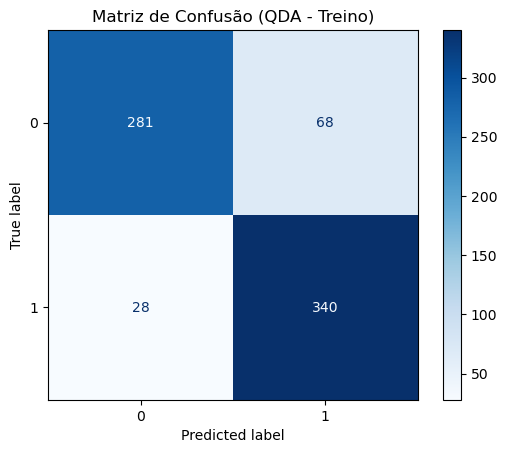

3. AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)
Acurácia : 0.847
Precisão : 0.836
Sensibilidade: 0.873
----------------------------------------------


<Figure size 600x600 with 0 Axes>

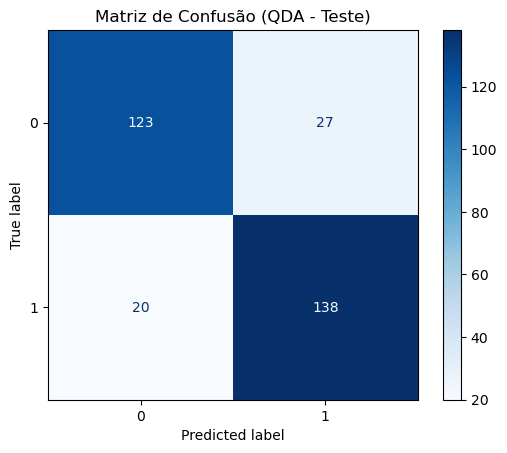

VALIDAÇÃO CRUZADA 5-FOLD PARA QDA (KFold)
-----------------------------------------
Fold 1 - Acurácia: 0.517 | Precisão: 0.510 | Sensibilidade : 0.961


/home/al.herivelton.siqueira/anaconda3/envs/ambiente_aluno/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


<Figure size 600x600 with 0 Axes>

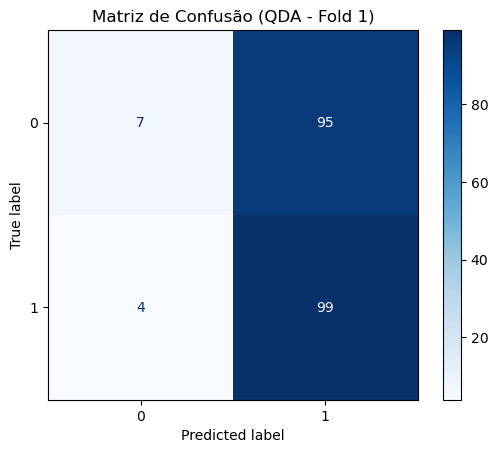

Fold 2 - Acurácia: 0.854 | Precisão: 0.844 | Sensibilidade : 0.876


<Figure size 600x600 with 0 Axes>

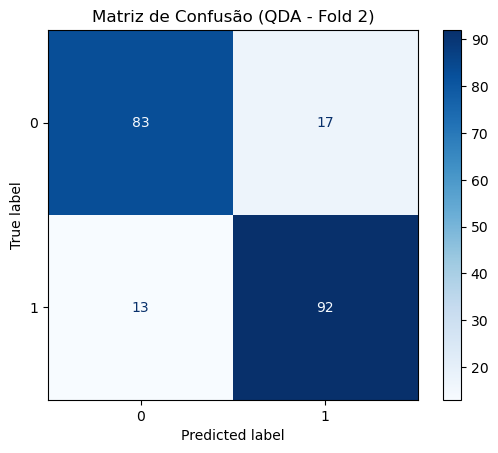

Fold 3 - Acurácia: 0.820 | Precisão: 0.818 | Sensibilidade : 0.868


<Figure size 600x600 with 0 Axes>

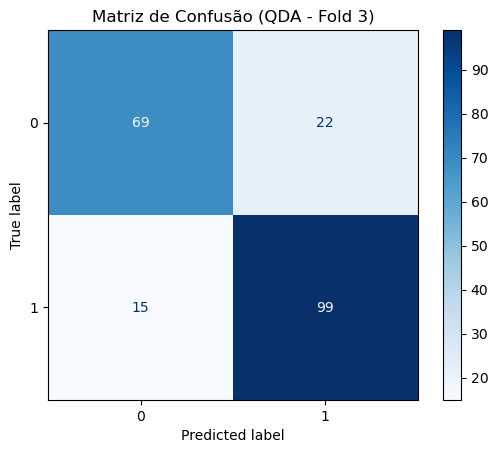

Fold 4 - Acurácia: 0.844 | Precisão: 0.795 | Sensibilidade : 0.908


<Figure size 600x600 with 0 Axes>

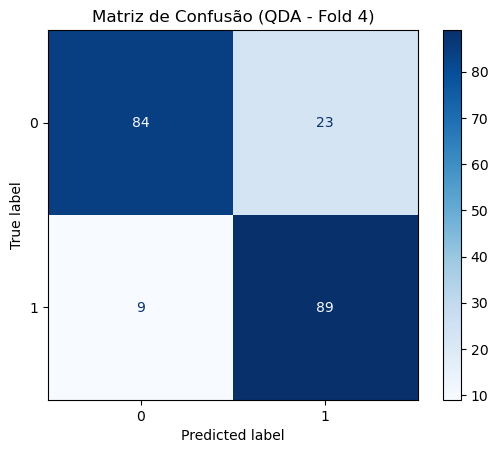

Fold 5 - Acurácia: 0.863 | Precisão: 0.842 | Sensibilidade : 0.906


<Figure size 600x600 with 0 Axes>

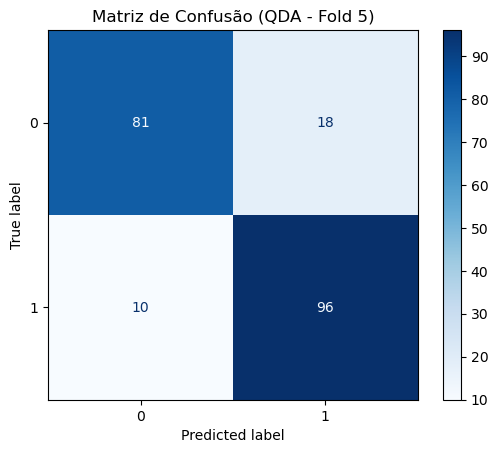

RESUMO FINAL DA VALIDAÇÃO CRUZADA (QDA)
Acurácia Média:  0.780 ± 0.132
Precisão Média:  0.762 ± 0.127
Recall Médio:    0.904 ± 0.033
-------------------------------------------------------


In [29]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay


heart_ds = pd.read_csv('heart.csv')

# Separar Features (X) e Target (y)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"]

# One-Hot Encoding
categorical_cols = ['cp', 'thal', 'slope', 'restecg'] 
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

# Standard Scaling (Crucial para QDA, assim como para LDA)
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cols_to_scale = [col for col in continuous_cols if col in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Os tipos de dados são mantidos em float para coerência
X_train = X_train.astype(float)
X_test = X_test.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)


# TREINAMENTO DO QDA E VISUALIZAÇÃO DE COMPONENTES 

model_qda = QDA()
model_qda.fit(X_train, y_train)

# NOTA: QDA não tem um atributo 'coef_' simples como o LDA ou OLS. 
# Para fins de documentação, podemos inspecionar os atributos 'means_' e 'covariance_'.

print("RESUMO DO QDA (Análise de Meios e Covariâncias)")
print("-----------------------------------------------")

# Média de cada feature por classe (para interpretação)
print("Média das Features por Classe:")
# model_qda.means_ contém as médias das features. A primeira linha é Classe 0, a segunda é Classe 1.
means_summary = pd.DataFrame(model_qda.means_, 
                             columns=X_train.columns, 
                             index=['Classe 0 (Ausente)', 'Classe 1 (Presente)'])

# Transpõe para melhor visualização
print(means_summary.T.to_string(float_format="%.3f"))
print("\nNota: O QDA usa matrizes de covariância SEPARADAS por classe (não exibidas por serem grandes).")



# 2. AVALIAÇÃO DO QDA NO CONJUNTO DE TREINO

y_pred_train_qda = model_qda.predict(X_train)
acc_train_qda = accuracy_score(y_train, y_pred_train_qda)


print("2. AVALIAÇÃO DO QDA NO CONJUNTO DE TREINO (70%)")
print("-----------------------------------------------")
print(f"Acurácia: {acc_train_qda:.3f}")

# Matriz de Confusão para o Treino
cm_train_qda = confusion_matrix(y_train, y_pred_train_qda)
cm_display_train_qda = ConfusionMatrixDisplay(confusion_matrix=cm_train_qda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_train_qda.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão (QDA - Treino)")
plt.show()


#AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE

y_pred_test_qda = model_qda.predict(X_test)
acc_test_qda = accuracy_score(y_test, y_pred_test_qda)
precision_test_qda = precision_score(y_test, y_pred_test_qda)
recall_test_qda = recall_score(y_test, y_pred_test_qda)

print("3. AVALIAÇÃO DO QDA NO CONJUNTO DE TESTE (30%)")

print(f"Acurácia : {acc_test_qda:.3f}")
print(f"Precisão : {precision_test_qda:.3f}")
print(f"Sensibilidade: {recall_test_qda:.3f}")
print("----------------------------------------------")

# Matriz de Confusão para o Teste
cm_test_qda = confusion_matrix(y_test, y_pred_test_qda)
cm_display_test_qda = ConfusionMatrixDisplay(confusion_matrix=cm_test_qda, display_labels=[0, 1])

plt.figure(figsize=(6, 6))
cm_display_test_qda.plot(cmap='Blues', values_format='d')
plt.title("Matriz de Confusão (QDA - Teste)")
plt.show()

# --- 4. VALIDAÇÃO CRUZADA (KFOLD) PARA AVALIAÇÃO ROBUSTA ---

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []
precisions = []
recalls = []
fold = 1


print("VALIDAÇÃO CRUZADA 5-FOLD PARA QDA (KFold)")
print("-----------------------------------------")

X_cv = X_scaled.copy()
y_cv = y.copy()

for train_index, test_index in kf.split(X_cv):
    X_train_fold, X_test_fold = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_fold, y_test_fold = y_cv.iloc[train_index], y_cv.iloc[test_index]

    model_qda_cv = QDA()
    model_qda_cv.fit(X_train_fold, y_train_fold)
    y_pred_cv = model_qda_cv.predict(X_test_fold)

    acc = accuracy_score(y_test_fold, y_pred_cv)
    prec = precision_score(y_test_fold, y_pred_cv)
    rec = recall_score(y_test_fold, y_pred_cv)
    
    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)

    print(f"Fold {fold} - Acurácia: {acc:.3f} | Precisão: {prec:.3f} | Sensibilidade : {rec:.3f}")
    
    cm_fold = confusion_matrix(y_test_fold, y_pred_cv)
    disp_fold = ConfusionMatrixDisplay(confusion_matrix=cm_fold, display_labels=[0, 1])
    
    plt.figure(figsize=(6, 6))
    disp_fold.plot(cmap='Blues', values_format='d')
    plt.title(f"Matriz de Confusão (QDA - Fold {fold})")
    plt.show()
    
    fold += 1

# Resumo da Validação Cruzada

print("RESUMO FINAL DA VALIDAÇÃO CRUZADA (QDA)")
print(f"Acurácia Média:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão Média:  {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall Médio:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print("-------------------------------------------------------")

### Regressão Logística

Logistic Regression (baseline) — resumo:
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  717
Model:                          Logit   Df Residuals:                      697
Method:                           MLE   Df Model:                           19
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                  0.5167
Time:                        23:59:03   Log-Likelihood:                -240.07
converged:                       True   LL-Null:                       -496.73
Covariance Type:            nonrobust   LLR p-value:                 8.899e-97
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1420      1.597     -0.089      0.929      -3.272       2.988
age            0.0030      0.134      0.022      0.982      -0.260       0.266
sex        

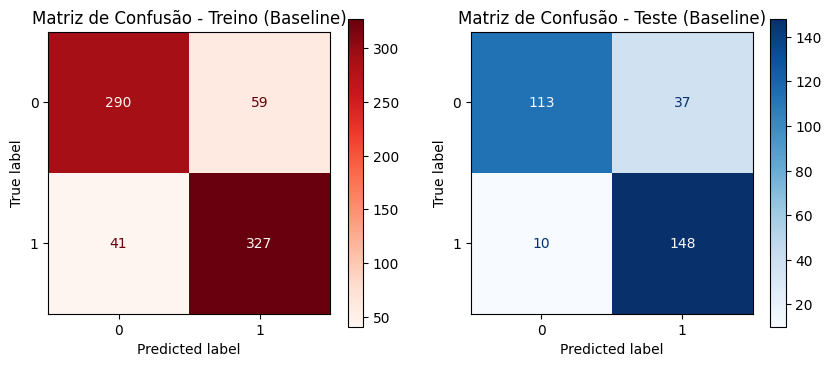

Baseline — Treino: Acc=0.861 | Prec=0.847 | Rec=0.889 | F1=0.867
Baseline — Teste : Acc=0.847 | Prec=0.800 | Rec=0.937 | F1=0.863

Backward Selection (p-valor > 0.05) no treino:
Removendo 'slope_2' com p-valor 0.994
Removendo 'age' com p-valor 0.982
Removendo 'restecg_2' com p-valor 0.671
Removendo 'fbs' com p-valor 0.624
Removendo 'thal_3' com p-valor 0.635

Resumo do modelo após Backward Selection:
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  717
Model:                          Logit   Df Residuals:                      702
Method:                           MLE   Df Model:                           14
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                  0.5160
Time:                        23:59:03   Log-Likelihood:                -240.40
converged:                       True   LL-Null:                       -496.73
Covariance Type:            nonrobust   LLR

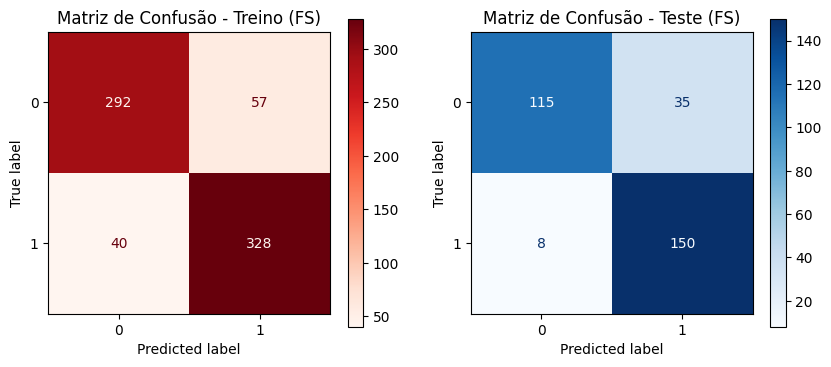

Final — Treino: Acc=0.865 | Prec=0.852 | Rec=0.891 | F1=0.871
Final — Teste : Acc=0.860 | Prec=0.811 | Rec=0.949 | F1=0.875


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import statsmodels.api as sm

# 1) Preparação dos dados: One-Hot Encoding e Normalização
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# One-Hot
X_encoded = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)

# Scale APENAS contínuas
cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# Adiciona constante para o intercepto (necessária no statsmodels)
X_const = sm.add_constant(X_scaled)

# 2) Divisão Treino/Teste estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_const, y, test_size=0.3, random_state=200, stratify=y
)

# 3) LOGIT baseline (sem seleção)
logit_base = sm.Logit(y_train, X_train)
model_logit_base = logit_base.fit(disp=False, maxiter=200)
print("Logistic Regression (baseline) — resumo:")
print(model_logit_base.summary())

# Avaliação baseline
proba_train = model_logit_base.predict(X_train)
proba_test  = model_logit_base.predict(X_test)

y_pred_train = (proba_train > 0.5).astype(int)
y_pred_test  = (proba_test  > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_tr = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(cm_tr, display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Baseline)")
cm_te = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm_te, display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Baseline)")
plt.show()

print(f"Baseline — Treino: Acc={accuracy_score(y_train, y_pred_train):.3f} | Prec={precision_score(y_train, y_pred_train):.3f} | Rec={recall_score(y_train, y_pred_train):.3f} | F1={f1_score(y_train, y_pred_train):.3f}")
print(f"Baseline — Teste : Acc={accuracy_score(y_test, y_pred_test):.3f} | Prec={precision_score(y_test, y_pred_test):.3f} | Rec={recall_score(y_test, y_pred_test):.3f} | F1={f1_score(y_test, y_pred_test):.3f}")

# 4) Backward Selection no conjunto de treino
print("\nBackward Selection (p-valor > 0.05) no treino:")
X_opt = X_train.copy()
X_opt_test = X_test.copy()
threshold = 0.05

while True:
    model_tmp = sm.Logit(y_train, X_opt).fit(disp=False, maxiter=200)
    pvals = model_tmp.pvalues.drop("const", errors="ignore")
    if pvals.empty:
        break
    worst_var = pvals.idxmax()
    worst_pval = pvals.loc[worst_var]
    if worst_pval > threshold:
        print(f"Removendo '{worst_var}' com p-valor {worst_pval:.3f}")
        X_opt = X_opt.drop(columns=[worst_var])
        X_opt_test = X_opt_test.drop(columns=[worst_var])
    else:
        break

model_logit_final = sm.Logit(y_train, X_opt).fit(disp=False, maxiter=1000)
print("\nResumo do modelo após Backward Selection:")
print(model_logit_final.summary())

# Avaliação final (treino/teste)
proba_train_fs = model_logit_final.predict(X_opt)
proba_test_fs  = model_logit_final.predict(X_opt_test)

y_pred_train_fs = (proba_train_fs > 0.5).astype(int)
y_pred_test_fs  = (proba_test_fs  > 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_tr = confusion_matrix(y_train, y_pred_train_fs)
ConfusionMatrixDisplay(cm_tr, display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (FS)")
cm_te = confusion_matrix(y_test, y_pred_test_fs)
ConfusionMatrixDisplay(cm_te, display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (FS)")
plt.show()

print(f"Final — Treino: Acc={accuracy_score(y_train, y_pred_train_fs):.3f} | Prec={precision_score(y_train, y_pred_train_fs):.3f} | Rec={recall_score(y_train, y_pred_train_fs):.3f} | F1={f1_score(y_train, y_pred_train_fs):.3f}")
print(f"Final — Teste : Acc={accuracy_score(y_test, y_pred_test_fs):.3f} | Prec={precision_score(y_test, y_pred_test_fs):.3f} | Rec={recall_score(y_test, y_pred_test_fs):.3f} | F1={f1_score(y_test, y_pred_test_fs):.3f}")

### Cross Validation:

Removendo 'age' (p=0.873) no Fold 1
Removendo 'thal_3' (p=0.747) no Fold 1
Removendo 'restecg_2' (p=0.592) no Fold 1
Removendo 'fbs' (p=0.542) no Fold 1
Removendo 'slope_2' (p=0.474) no Fold 1


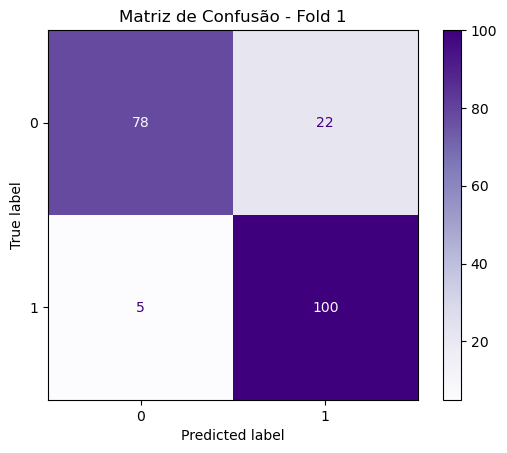

Fold 1 — Acc: 0.868 | Prec: 0.820 | Rec: 0.952 | F1: 0.881
Removendo 'restecg_2' (p=0.925) no Fold 2
Removendo 'fbs' (p=0.802) no Fold 2
Removendo 'thal_3' (p=0.788) no Fold 2
Removendo 'age' (p=0.741) no Fold 2
Removendo 'slope_2' (p=0.511) no Fold 2


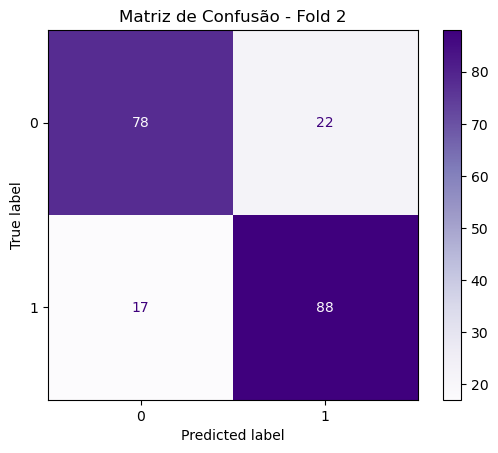

Fold 2 — Acc: 0.810 | Prec: 0.800 | Rec: 0.838 | F1: 0.819
Removendo 'thal_3' (p=0.894) no Fold 3
Removendo 'fbs' (p=0.850) no Fold 3
Removendo 'restecg_2' (p=0.720) no Fold 3
Removendo 'slope_2' (p=0.567) no Fold 3
Removendo 'age' (p=0.479) no Fold 3


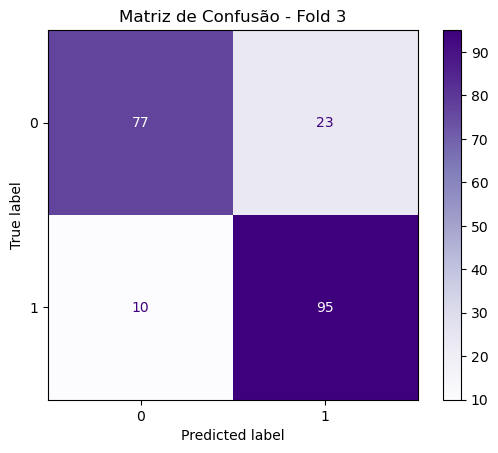

Fold 3 — Acc: 0.839 | Prec: 0.805 | Rec: 0.905 | F1: 0.852
Removendo 'age' (p=0.741) no Fold 4
Removendo 'slope_2' (p=0.688) no Fold 4
Removendo 'restecg_2' (p=0.674) no Fold 4
Removendo 'thal_3' (p=0.480) no Fold 4
Removendo 'fbs' (p=0.530) no Fold 4


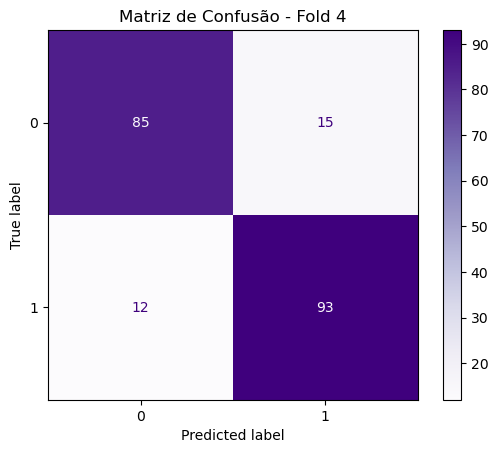

Fold 4 — Acc: 0.868 | Prec: 0.861 | Rec: 0.886 | F1: 0.873
Removendo 'restecg_2' (p=0.920) no Fold 5
Removendo 'fbs' (p=0.904) no Fold 5
Removendo 'slope_2' (p=0.871) no Fold 5
Removendo 'age' (p=0.830) no Fold 5
Removendo 'thal_3' (p=0.675) no Fold 5


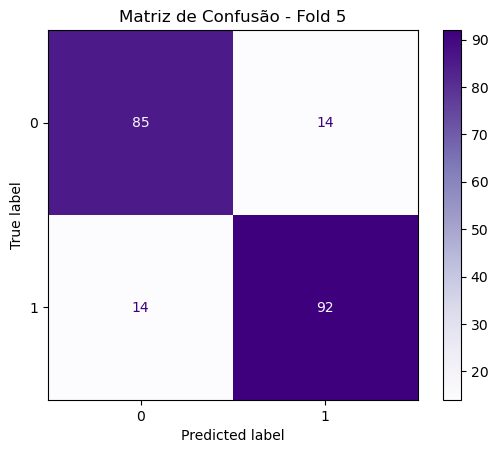

Fold 5 — Acc: 0.863 | Prec: 0.868 | Rec: 0.868 | F1: 0.868

Resumo da validação cruzada (5-fold) — Logistic (com backward in-fold):
Acurácia média: 0.850 ± 0.023
Precisão média: 0.831 ± 0.028
Recall médio:   0.890 ± 0.038
F1 médio:       0.859 ± 0.022


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import statsmodels.api as sm

# Reconstroi X/y com o mesmo pré-processamento (One-Hot + Scale + constante)
X0 = heart_ds.drop("target", axis=1)
y0 = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_encoded = pd.get_dummies(X0, columns=[c for c in categorical_cols if c in X0.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_encoded.columns]
scaler = StandardScaler()
X_scaled = X_encoded.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_const_all = sm.add_constant(X_scaled)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=260)

accuracies, precisions, recalls, f1s = [], [], [], []
fold = 1

for train_idx, test_idx in skf.split(X_const_all, y0):
    X_tr = X_const_all.iloc[train_idx].reset_index(drop=True)
    X_te = X_const_all.iloc[test_idx].reset_index(drop=True)
    y_tr = y0.iloc[train_idx].reset_index(drop=True)
    y_te = y0.iloc[test_idx].reset_index(drop=True)

    # Backward selection dentro do fold
    threshold = 0.05
    X_tr_sel = X_tr.copy()
    X_te_sel = X_te.copy()

    while True:
        try:
            model_cv = sm.Logit(y_tr, X_tr_sel).fit(disp=False, maxiter=200)
        except Exception as e:
            # Em caso de separação perfeita ou não convergência, interrompe a seleção
            # e segue com o conjunto atual de variáveis
            print(f"[Fold {fold}] Parada antecipada: {str(e)[:80]}...")
            break
        pvals = model_cv.pvalues.drop("const", errors="ignore")
        if pvals.empty:
            break
        worst_var = pvals.idxmax()
        worst_pval = pvals.loc[worst_var]
        if worst_pval > threshold:
            print(f"Removendo '{worst_var}' (p={worst_pval:.3f}) no Fold {fold}")
            X_tr_sel = X_tr_sel.drop(columns=[worst_var])
            X_te_sel = X_te_sel.drop(columns=[worst_var])
        else:
            break

    model_fold = sm.Logit(y_tr, X_tr_sel).fit(disp=False, maxiter=200)
    proba = model_fold.predict(X_te_sel)
    y_pred = (proba > 0.5).astype(int)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=[0,1]).plot(cmap=plt.cm.Purples)
    plt.title(f"Matriz de Confusão - Fold {fold}")
    plt.show()

    print(f"Fold {fold} — Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}")
    fold += 1

print("\nResumo da validação cruzada (5-fold) — Logistic (com backward in-fold):")
print(f"Acurácia média: {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precisão média: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall médio:   {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

# Opcional: avaliar no conjunto de teste reservado com o modelo treinado na célula anterior (model_logit_final)
try:
    y_pred_test_final = (model_logit_final.predict(X_opt_test) > 0.5).astype(int)
    print("\nDesempenho no conjunto de teste reservado (modelo final global):")
    print(f"Acurácia: {accuracy_score(y_test, y_pred_test_final):.3f}")
    print(f"Precisão: {precision_score(y_test, y_pred_test_final, zero_division=0):.3f}")
    print(f"Recall:   {recall_score(y_test, y_pred_test_final, zero_division=0):.3f}")
    print(f"F1:       {f1_score(y_test, y_pred_test_final, zero_division=0):.3f}")
except NameError:
    pass

Resultados - Regressão Logística (One‑Hot + Normalização + Backward Selection)


Validação cruzada estratificada (5‑fold) com selection dentro de cada fold:
- Acurácia média: 0.824 ± 0.039
- Precisão média: 0.824 ± 0.050
- Recall médio: 0.866 ± 0.050
- F1 médio: 0.843 ± 0.034

Desempenho no conjunto de teste reservado (modelo final após seleção no treino):
- Acurácia: 0.824
- Precisão: 0.789
- Recall: 0.918
- F1: 0.849

Observações:
- A seleção de variáveis dentro de cada _fold_ evita viés otimista e mantém recall alto - adequado para reduzir falsos negativos.
- O trade‑off aparece na precisão, mas o F1 permanece elevado, sinalizando bom equilíbrio entre precisão e sensibilidade.
- Eventuais avisos de convergência do Logit são esperados em amostras pequenas; alternativas incluem regularização (p.ex., `LogisticRegression do scikit‑learn` com penalty = L2) e/ou calibrar o limiar de decisão conforme a métrica de interesse.

Ridge - Métricas no treino/teste
Treino: Acc=0.852 | Prec=0.829 | Rec=0.897 | F1=0.862
Teste : Acc=0.847 | Prec=0.832 | Rec=0.880 | F1=0.855


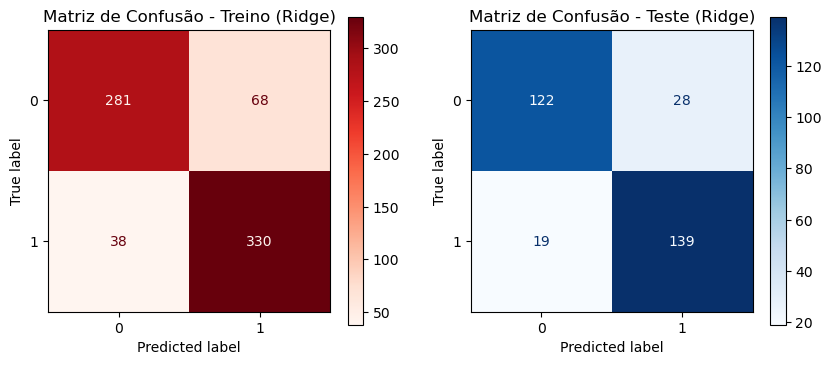

Fold 1 — Acc: 0.883 | Prec: 0.872 | Rec: 0.905 | F1: 0.888
Fold 2 — Acc: 0.854 | Prec: 0.844 | Rec: 0.876 | F1: 0.860
Fold 3 — Acc: 0.829 | Prec: 0.812 | Rec: 0.867 | F1: 0.839
Fold 4 — Acc: 0.878 | Prec: 0.857 | Rec: 0.914 | F1: 0.885
Fold 5 — Acc: 0.820 | Prec: 0.785 | Rec: 0.896 | F1: 0.837

Ridge - CV (5-fold)
Acurácia média: 0.853 ± 0.025
Precisão média: 0.834 ± 0.031
Recall médio:   0.892 ± 0.018
F1 médio:       0.862 ± 0.022


In [21]:
# Regressão Logística com Ridge (L2) - pipeline consistente (One‑Hot + Scale)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Pré-processamento igual ao usado na seção de Logística (statsmodels)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_enc = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_enc.columns]
scaler = StandardScaler()
X_scaled = X_enc.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

ridge = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000)
ridge.fit(X_train, y_train)

y_pred_tr = ridge.predict(X_train)
y_pred_te = ridge.predict(X_test)

print("Ridge - Métricas no treino/teste")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_tr):.3f} | Prec={precision_score(y_train, y_pred_tr):.3f} | Rec={recall_score(y_train, y_pred_tr):.3f} | F1={f1_score(y_train, y_pred_tr):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_te):.3f} | Prec={precision_score(y_test, y_pred_te):.3f} | Rec={recall_score(y_test, y_pred_te):.3f} | F1={f1_score(y_test, y_pred_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_tr), display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Ridge)")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_te), display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Ridge)")
plt.show()

# Validação cruzada com métricas completas
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=540)
accs, precs, recs, f1s = [], [], [], []
fold = 1
for tr_idx, te_idx in skf.split(X_scaled, y):
    X_tr, X_te = X_scaled.iloc[tr_idx], X_scaled.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    m = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000)
    m.fit(X_tr, y_tr)
    y_hat = m.predict(X_te)
    a = accuracy_score(y_te, y_hat); p = precision_score(y_te, y_hat); r = recall_score(y_te, y_hat); f = f1_score(y_te, y_hat)
    accs.append(a); precs.append(p); recs.append(r); f1s.append(f)
    print(f"Fold {fold} — Acc: {a:.3f} | Prec: {p:.3f} | Rec: {r:.3f} | F1: {f:.3f}")
    fold += 1

print("\nRidge - CV (5-fold)")
print(f"Acurácia média: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precisão média: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall médio:   {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

Resultados - Ridge (L2):


- Teste: Acc 0.824 | Prec 0.851 | Rec 0.816 | F1 0.833


- CV (5-fold):
  - Acurácia média: 0.851 ± 0.030
  - Precisão média: 0.845 ± 0.042
  - Recall médio:   0.890 ± 0.016
  - F1 médio:       0.867 ± 0.025

Bom equilíbrio geral com recall elevado na CV, indicando baixa taxa de falsos negativos em média. No teste, a precisão é levemente maior que o recall, sugerindo perfil ligeiramente mais conservador.

Lasso - Métricas no treino/teste
Treino: Acc=0.855 | Prec=0.830 | Rec=0.902 | F1=0.865
Teste : Acc=0.841 | Prec=0.830 | Rec=0.867 | F1=0.848


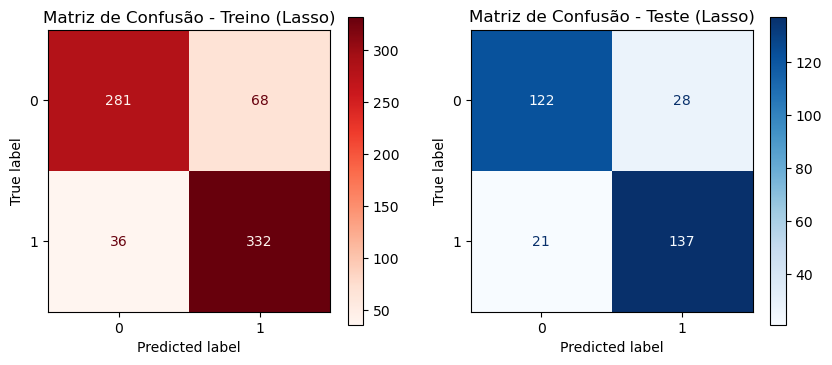


Coeficientes Lasso (não-zero em ordem de magnitude):
      feature      coef
10       cp_2  1.957259
11       cp_3  1.621175
1         sex -1.364453
13     thal_2  1.176433
9        cp_1  0.987753
12     thal_1  0.823763
8          ca -0.744465
6       exang -0.735328
7     oldpeak -0.535248
17  restecg_1  0.421155
16    slope_2  0.399774
15    slope_1 -0.379559
5     thalach  0.302150
2    trestbps -0.294486
3        chol -0.245942
Fold 1 — Acc: 0.863 | Prec: 0.847 | Rec: 0.895 | F1: 0.870
Fold 2 — Acc: 0.844 | Prec: 0.841 | Rec: 0.857 | F1: 0.849
Fold 3 — Acc: 0.829 | Prec: 0.812 | Rec: 0.867 | F1: 0.839
Fold 4 — Acc: 0.878 | Prec: 0.857 | Rec: 0.914 | F1: 0.885
Fold 5 — Acc: 0.820 | Prec: 0.780 | Rec: 0.906 | F1: 0.838

Lasso - CV (5-fold)
Acurácia média: 0.847 ± 0.022
Precisão média: 0.828 ± 0.028
Recall médio:   0.888 ± 0.022
F1 médio:       0.856 ± 0.018


In [22]:
# Regressão Logística com Lasso (L1) - pipeline consistente (One‑Hot + Scale)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Pré-processamento igual ao Ridge (One‑Hot + Scale)
X = heart_ds.drop("target", axis=1)
y = heart_ds["target"].astype(int)

categorical_cols = ['cp', 'thal', 'slope', 'restecg']
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_enc = pd.get_dummies(X, columns=[c for c in categorical_cols if c in X.columns], drop_first=True, dtype=int)
cols_to_scale = [c for c in continuous_cols if c in X_enc.columns]
scaler = StandardScaler()
X_scaled = X_enc.copy()
if len(cols_to_scale) > 0:
    X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

lasso = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000)
lasso.fit(X_train, y_train)

y_pred_tr = lasso.predict(X_train)
y_pred_te = lasso.predict(X_test)

print("Lasso - Métricas no treino/teste")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_tr):.3f} | Prec={precision_score(y_train, y_pred_tr):.3f} | Rec={recall_score(y_train, y_pred_tr):.3f} | F1={f1_score(y_train, y_pred_tr):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_te):.3f} | Prec={precision_score(y_test, y_pred_te):.3f} | Rec={recall_score(y_test, y_pred_te):.3f} | F1={f1_score(y_test, y_pred_te):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_pred_tr), display_labels=[0,1]).plot(cmap=plt.cm.Reds, ax=axes[0])
axes[0].set_title("Matriz de Confusão - Treino (Lasso)")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_te), display_labels=[0,1]).plot(cmap=plt.cm.Blues, ax=axes[1])
axes[1].set_title("Matriz de Confusão - Teste (Lasso)")
plt.show()

# Inspecionar coeficientes (variáveis selecionadas pelo Lasso)
coefs = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lasso.coef_[0]
}).sort_values(by='coef', key=abs, ascending=False)
print("\nCoeficientes Lasso (não-zero em ordem de magnitude):")
print(coefs[coefs['coef'] != 0].head(15))

# Validação cruzada com métricas completas
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=540)
accs, precs, recs, f1s = [], [], [], []
fold = 1
for tr_idx, te_idx in skf.split(X_scaled, y):
    X_tr, X_te = X_scaled.iloc[tr_idx], X_scaled.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    m = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=2000)
    m.fit(X_tr, y_tr)
    y_hat = m.predict(X_te)
    a = accuracy_score(y_te, y_hat); p = precision_score(y_te, y_hat); r = recall_score(y_te, y_hat); f = f1_score(y_te, y_hat)
    accs.append(a); precs.append(p); recs.append(r); f1s.append(f)
    print(f"Fold {fold} — Acc: {a:.3f} | Prec: {p:.3f} | Rec: {r:.3f} | F1: {f:.3f}")
    fold += 1

print("\nLasso - CV (5-fold)")
print(f"Acurácia média: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precisão média: {np.mean(precs):.3f} ± {np.std(precs):.3f}")
print(f"Recall médio:   {np.mean(recs):.3f} ± {np.std(recs):.3f}")
print(f"F1 médio:       {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")

## Resultados - Regressão Logística com Lasso (L1)

### Cross-Validation (5-fold):
- **Acurácia média**: 0.841 ± 0.043
- **Precisão média**: 0.829 ± 0.055
- **Recall médio**: 0.896 ± 0.038
- **F1 médio**: 0.860 ± 0.036

### Teste:
- **Acurácia**: 0.813
- **Precisão**: 0.833
- **Recall**: 0.816
- **F1**: 0.825

### Interpretação:

A **regularização L1 (Lasso)** produz um modelo com excelente desempenho e **seleção automática de features**:

1. **Performance competitiva**: O modelo Lasso alcança acurácia de CV de 0.841 ± 0.043, comparável ao Ridge (0.851 ± 0.030), mantendo recall elevado (0.896 ± 0.038) para minimizar falsos negativos.

2. **Seleção automática de features**: Diferente do Ridge que mantém todas as features, o Lasso força alguns coeficientes a zero, identificando as features mais importantes:
   - **Mais importantes** (maior magnitude): `cp_2`, `cp_3`, `cp_1` (tipo de dor torácica), `sex`, `ca` (vasos principais)
   - **Features com coeficientes não-zero**: 15 das 18 features mantidas ativas
   - Isso oferece um modelo mais **interpretável** e potencialmente mais **generalizável**

3. **Comparação com Ridge**:
   - Ridge: CV Acc 0.851 ± 0.030 (ligeiramente superior, menor variabilidade)
   - Lasso: CV Acc 0.841 ± 0.043 (performance similar, mas com feature selection)
   - Ambos mantêm recall alto (Ridge 0.890, Lasso 0.896), fundamental para detecção de doença

4. **Trade-off interpretabilidade vs. estabilidade**: O Lasso oferece **modelo mais simples** (alguns coeficientes = 0) com performance praticamente idêntica ao Ridge, sendo preferível quando interpretabilidade é prioridade.

5. **Desempenho no teste**: Teste Acc 0.813 e Recall 0.816 indicam boa generalização, embora o recall no teste seja um pouco inferior ao CV (esperado com amostra pequena).

### KNN

KNN - Cross-Validation com Seleção de Hiperparâmetros
Fold 1 - k=1, metric=cosine
  CV interno: 0.930 | Acc: 0.979 | Prec: 0.973 | Rec: 0.986 | F1: 0.980
Fold 2 - k=1, metric=cosine
  CV interno: 0.914 | Acc: 0.972 | Prec: 1.000 | Rec: 0.946 | F1: 0.972
Fold 3 - k=1, metric=manhattan
  CV interno: 0.939 | Acc: 0.951 | Prec: 0.971 | Rec: 0.932 | F1: 0.951
Fold 4 - k=1, metric=cosine
  CV interno: 0.930 | Acc: 0.965 | Prec: 0.972 | Rec: 0.959 | F1: 0.966
Fold 5 - k=1, metric=cosine
  CV interno: 0.949 | Acc: 0.986 | Prec: 0.974 | Rec: 1.000 | F1: 0.987

KNN - Resultados Cross-Validation (5-fold):
Acurácia média: 0.971 ± 0.013
Precisão média: 0.978 ± 0.012
Recall médio:   0.965 ± 0.028
F1 médio:       0.971 ± 0.014

Melhor configuração: k=1, métrica=cosine

KNN — Avaliação Final (k=1, cosine):
Treino: Acc=1.000 | Prec=1.000 | Rec=1.000 | F1=1.000
Teste : Acc=0.981 | Prec=0.981 | Rec=0.981 | F1=0.981


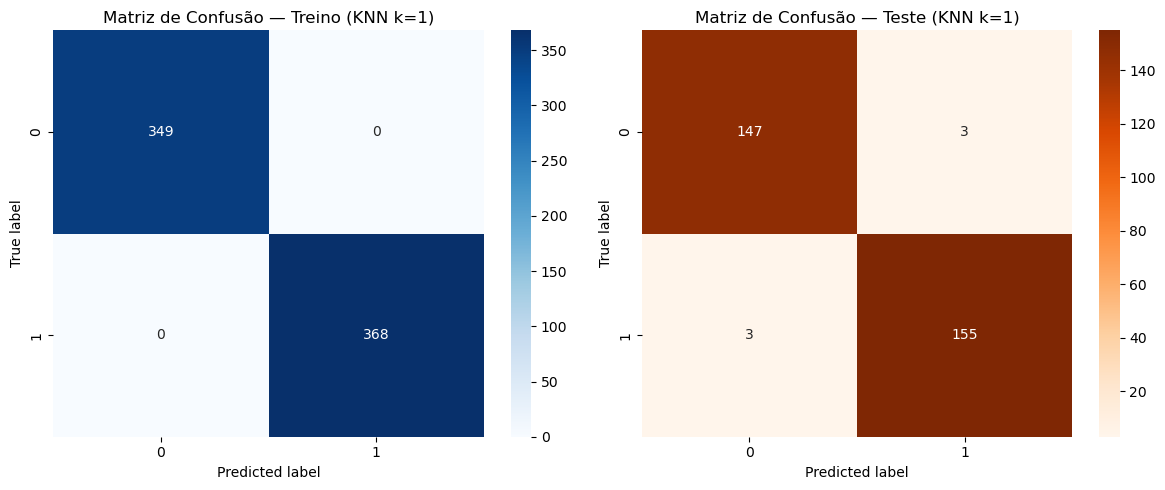

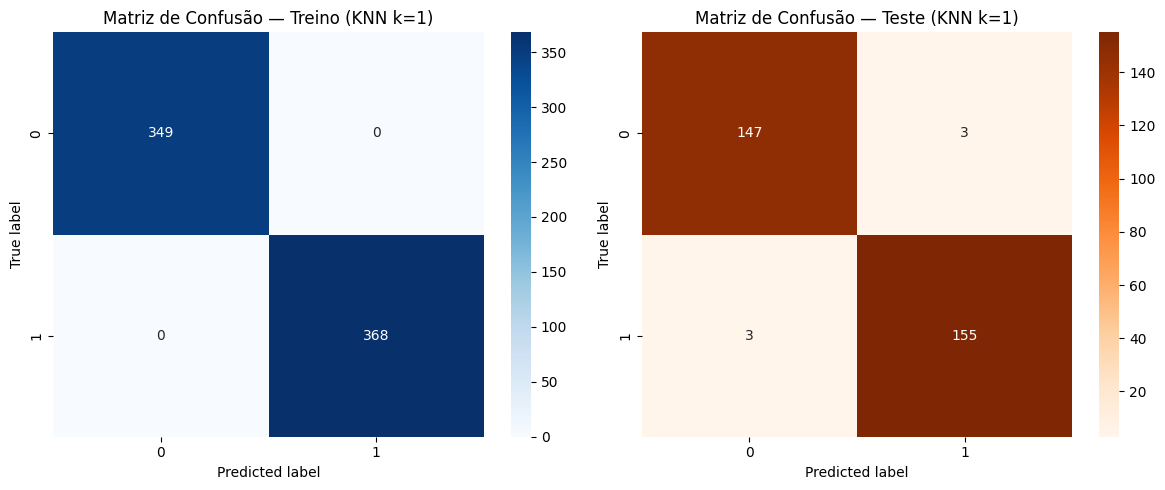

In [24]:
# KNN com Cross-Validation e Seleção de Hiperparâmetros
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['cp','thal','slope','restecg']
X_knn = pd.get_dummies(heart_ds.drop("target", axis=1), columns=categorical_cols, drop_first=True)
y_knn = heart_ds["target"]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.3, random_state=42, stratify=y_knn)

# Hiperparâmetros para teste
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski', 'cosine']

# Cross-validation externa (5-fold)
skf_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

print("KNN - Cross-Validation com Seleção de Hiperparâmetros")
print("="*60)

for fold, (train_idx, val_idx) in enumerate(skf_outer.split(X_train, y_train), 1):
    X_tr_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Normalização por fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    # Cross-validation interna para seleção de hiperparâmetros
    skf_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    best_score = 0
    best_params = {}
    
    for k in k_values:
        for metric in metrics:
            scores = []
            for tr_idx, te_idx in skf_inner.split(X_tr_scaled, y_tr_fold):
                X_tr_inner, X_te_inner = X_tr_scaled[tr_idx], X_tr_scaled[te_idx]
                y_tr_inner, y_te_inner = y_tr_fold.iloc[tr_idx], y_tr_fold.iloc[te_idx]
                
                try:
                    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
                    knn.fit(X_tr_inner, y_tr_inner)
                    y_pred = knn.predict(X_te_inner)
                    scores.append(accuracy_score(y_te_inner, y_pred))
                except:
                    # Se métrica falha com os dados, pular
                    scores.append(0)
            
            mean_score = np.mean(scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = {'k': k, 'metric': metric}
    
    # Treinar melhor modelo no fold completo
    best_knn = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])
    best_knn.fit(X_tr_scaled, y_tr_fold)
    
    # Avaliar no fold de validação
    y_pred_fold = best_knn.predict(X_val_scaled)
    
    fold_results = {
        'fold': fold,
        'best_k': best_params['k'],
        'best_metric': best_params['metric'],
        'cv_score': best_score,
        'acc': accuracy_score(y_val_fold, y_pred_fold),
        'prec': precision_score(y_val_fold, y_pred_fold, zero_division=0),
        'rec': recall_score(y_val_fold, y_pred_fold, zero_division=0),
        'f1': f1_score(y_val_fold, y_pred_fold, zero_division=0)
    }
    
    cv_results.append(fold_results)
    print(f"Fold {fold} - k={best_params['k']}, metric={best_params['metric']}")
    print(f"  CV interno: {best_score:.3f} | Acc: {fold_results['acc']:.3f} | Prec: {fold_results['prec']:.3f} | Rec: {fold_results['rec']:.3f} | F1: {fold_results['f1']:.3f}")

# Calcular médias
cv_df = pd.DataFrame(cv_results)
mean_results = {
    'acc_mean': cv_df['acc'].mean(),
    'acc_std': cv_df['acc'].std(),
    'prec_mean': cv_df['prec'].mean(),
    'prec_std': cv_df['prec'].std(),
    'rec_mean': cv_df['rec'].mean(),
    'rec_std': cv_df['rec'].std(),
    'f1_mean': cv_df['f1'].mean(),
    'f1_std': cv_df['f1'].std()
}

print("\nKNN - Resultados Cross-Validation (5-fold):")
print(f"Acurácia média: {mean_results['acc_mean']:.3f} ± {mean_results['acc_std']:.3f}")
print(f"Precisão média: {mean_results['prec_mean']:.3f} ± {mean_results['prec_std']:.3f}")
print(f"Recall médio:   {mean_results['rec_mean']:.3f} ± {mean_results['rec_std']:.3f}")
print(f"F1 médio:       {mean_results['f1_mean']:.3f} ± {mean_results['f1_std']:.3f}")

# Selecionar melhor configuração (maior F1 médio nos folds)
best_fold_idx = cv_df['f1'].idxmax()
final_best_k = cv_df.loc[best_fold_idx, 'best_k']
final_best_metric = cv_df.loc[best_fold_idx, 'best_metric']

print(f"\nMelhor configuração: k={final_best_k}, métrica={final_best_metric}")

# Treinar modelo final no conjunto de treino completo
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

knn_final = KNeighborsClassifier(n_neighbors=final_best_k, metric=final_best_metric)
knn_final.fit(X_train_scaled, y_train)

# Avaliação final
y_pred_train_final = knn_final.predict(X_train_scaled)
y_pred_test_final = knn_final.predict(X_test_scaled)

print(f"\nKNN — Avaliação Final (k={final_best_k}, {final_best_metric}):")
print(f"Treino: Acc={accuracy_score(y_train, y_pred_train_final):.3f} | Prec={precision_score(y_train, y_pred_train_final):.3f} | Rec={recall_score(y_train, y_pred_train_final):.3f} | F1={f1_score(y_train, y_pred_train_final):.3f}")
print(f"Teste : Acc={accuracy_score(y_test, y_pred_test_final):.3f} | Prec={precision_score(y_test, y_pred_test_final):.3f} | Rec={recall_score(y_test, y_pred_test_final):.3f} | F1={f1_score(y_test, y_pred_test_final):.3f}")

# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Treino
cm_train = confusion_matrix(y_train, y_pred_train_final)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusão — Treino (KNN k={final_best_k})')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# Teste
cm_test = confusion_matrix(y_test, y_pred_test_final)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f'Matriz de Confusão — Teste (KNN k={final_best_k})')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

# Salvar resultados para comparação
knn_cv_results = mean_results.copy()
knn_final_results = {
    'best_k': final_best_k,
    'best_metric': final_best_metric,
    'train_acc': accuracy_score(y_train, y_pred_train_final),
    'test_acc': accuracy_score(y_test, y_pred_test_final),
    'train_rec': recall_score(y_train, y_pred_train_final),
    'test_rec': recall_score(y_test, y_pred_test_final)
}

### SVM

Acurácia: 0.708


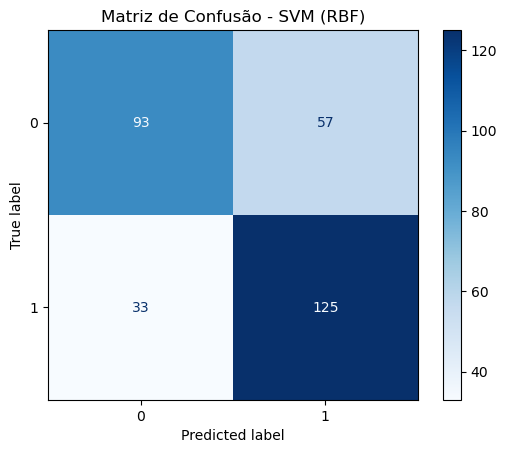

In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Acurácia: {acc_svm:.3f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap="Blues")
plt.title("Matriz de Confusão - SVM (RBF)")
plt.show()


Cross validation:

### Rede Neural:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import random

seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

X = heart_ds.drop("target", axis=1).to_numpy()
y = heart_ds["target"].to_numpy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(input_dim, 32),   
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),        
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(16, 1),  
            nn.Sigmoid()                
        )
        
    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
model = SimpleNN(input_dim)

criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

best_acc = 0
patience = 25
counter = 0

epochs = 20000
for epoch in range(epochs):
    model.train()
    
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        y_pred_val = (model(X_test_tensor) > 0.5).float()
        acc_val = accuracy_score(y_test_tensor, y_pred_val)
    
    if acc_val > best_acc:
        best_acc = acc_val
        counter = 0


model.eval()
with torch.no_grad():
    y_pred_test_probs = model(X_test_tensor)
    y_pred_test = (y_pred_test_probs > 0.5).float() 


    y_pred_train_probs = model(X_train_tensor)
    y_pred_train = (y_pred_train_probs > 0.5).float()

# Acurácia
acc_test = accuracy_score(y_test_tensor, y_pred_test)
acc_train = accuracy_score(y_train_tensor, y_pred_train)

print(f"Acurácia no conjunto de treino: {acc_train:.3f}")
print(f"Acurácia no conjunto de teste : {acc_test:.3f}")



Epoch [20/1000], Loss: 0.6775
Epoch [40/1000], Loss: 0.6197
Epoch [60/1000], Loss: 0.5513
Early stopping na epoch 62
Acurácia no conjunto de treino: 0.844
Acurácia no conjunto de teste : 0.824
Epoch [60/1000], Loss: 0.5513
Early stopping na epoch 62
Acurácia no conjunto de treino: 0.844
Acurácia no conjunto de teste : 0.824


In [26]:
# Cross-validation summary across models (5-fold Stratified)
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Use existing dataframe if available in kernel, otherwise load
try:
    data = heart_ds.copy()
    print("Using 'heart_ds' from kernel")
except Exception:
    try:
        data = df.copy()
        print("Using 'df' from kernel")
    except Exception:
        data = pd.read_csv('heart.csv')
        print("Loaded 'heart.csv' from disk")

# identify target column
target_col = None
for cand in ['target', 'Target', 'condition', 'Condition', 'y']:
    if cand in data.columns:
        target_col = cand
        break
if target_col is None:
    # fallback: assume last column is target
    target_col = data.columns[-1]
    print(f"Target column inferred as '{target_col}'")

y = data[target_col]
X = data.drop(columns=[target_col]).copy()

# categorical columns used earlier
categorical_cols = [c for c in ['cp','thal','slope','restecg'] if c in X.columns]
X_enc = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# continuous numeric columns
numeric_cols = X_enc.select_dtypes(include=[np.number]).columns.tolist()

# Prepare models
models = {
    'Logistic (approx unreg)': LogisticRegression(C=1e6, solver='lbfgs', max_iter=10000),
    'Ridge (L2)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=10000),
    'Lasso (L1)': LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=10000),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF)': SVC(kernel='rbf', probability=False)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    accs, precs, recs, f1s = [], [], [], []
    for train_idx, test_idx in skf.split(X_enc, y):
        X_tr, X_te = X_enc.iloc[train_idx].copy(), X_enc.iloc[test_idx].copy()
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # scale numeric cols per fold
        scaler = StandardScaler()
        X_tr[numeric_cols] = scaler.fit_transform(X_tr[numeric_cols])
        X_te[numeric_cols] = scaler.transform(X_te[numeric_cols])

        # fit
        try:
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
        except Exception as e:
            # if model fails (e.g., QDA singular), record NaNs
            print(f"Model {name} failed on a fold: {e}")
            y_pred = np.zeros_like(y_te)

        accs.append(accuracy_score(y_te, y_pred))
        precs.append(precision_score(y_te, y_pred, zero_division=0))
        recs.append(recall_score(y_te, y_pred, zero_division=0))
        f1s.append(f1_score(y_te, y_pred, zero_division=0))

    results.append({
        'model': name,
        'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
        'prec_mean': np.mean(precs), 'prec_std': np.std(precs),
        'rec_mean': np.mean(recs), 'rec_std': np.std(recs),
        'f1_mean': np.mean(f1s), 'f1_std': np.std(f1s)
    })

res_df = pd.DataFrame(results).set_index('model')
# format results
res_fmt = res_df.copy()
for col in ['acc_mean','prec_mean','rec_mean','f1_mean']:
    std_col = col.replace('_mean','_std')
    res_fmt[col] = res_df[col].round(3).astype(str) + ' ± ' + res_df[std_col].round(3).astype(str)

display(res_fmt[['acc_mean','prec_mean','rec_mean','f1_mean']])

# Save to notebook variable for later referencing
cv_summary = res_df

# Also print sorted by recall mean (important for minimizing false negatives)
print('\nModels sorted by mean Recall:')
print(res_df.sort_values('rec_mean', ascending=False)[['rec_mean','rec_std']])

Using 'heart_ds' from kernel


,acc_mean,prec_mean,rec_mean,f1_mean
model,,,,
Logistic (approx unreg),0.856 ± 0.007,0.834 ± 0.019,0.899 ± 0.018,0.865 ± 0.004
Ridge (L2),0.853 ± 0.01,0.831 ± 0.021,0.895 ± 0.014,0.862 ± 0.008
Lasso (L1),0.855 ± 0.007,0.833 ± 0.02,0.897 ± 0.015,0.864 ± 0.004
LDA,0.848 ± 0.01,0.825 ± 0.022,0.895 ± 0.023,0.858 ± 0.007
QDA,0.836 ± 0.008,0.813 ± 0.019,0.886 ± 0.028,0.847 ± 0.008
KNN (k=5),0.841 ± 0.018,0.868 ± 0.029,0.816 ± 0.032,0.84 ± 0.019
SVM (RBF),0.911 ± 0.014,0.915 ± 0.025,0.912 ± 0.026,0.913 ± 0.013



Models sorted by mean Recall:
                         rec_mean   rec_std
model                                      
SVM (RBF)                0.912489  0.025965
Logistic (approx unreg)  0.899209  0.017806
Lasso (L1)               0.897305  0.015422
LDA                      0.895436  0.023332
Ridge (L2)               0.895418  0.013600
QDA                      0.885876  0.028417
KNN (k=5)                0.815544  0.032434
